# P1b: Counter-UAS SSG with 2D Cost Map

Scaffold notebook for Step 1: project setup, parameters, and architecture.

This notebook follows the COMPUTE / PLOT cell convention: COMPUTE cells save outputs to `data/*.json`, and PLOT cells load those files without recomputing.

In [ ]:
# IMPORTS & CONFIG
import os
import json
import math

# Parameters
params = {
    # Physics / Vehicle
    'G': 9.81,
    'RHO': 1.225,
    'M': 1.5,
    'S': 0.1,
    'CD': 0.025,
    'V_STALL': 14.0,
    'V_MAX': 60.0,
    'T_MAX': 25.0,
    'TAU_GAMMA': 5.0,   # first-order lag time constant for gamma tracking (s)

    # Mission Geometry
    'Z_LAUNCH': 0.0, 'H_LAUNCH': 0.0,
    'Z_GOAL': 2500.0, 'H_GOAL': 0.0,
    'DT_GLIDE': 1.0, 'DT_POW': 1.0,
    'V_LAUNCH': 14.0,
    'GAM_LAUNCH': 45.0,

    # Terrain (Gaussian)
    'Z_RIDGE': 1250.0,
    'H_RIDGE': 100.0,
    'SIGMA_TERRAIN': 200.0,

    # Sensor (default placement)
    'Z_SENSOR': 2000.0,
    'H_SENSOR': 0.0,
    'LAM_DOPPLER': 1.33e6,   # ~5 orders larger than current 4.5e2
    'LAM_RCS':     5.2e8,  # ~7 orders larger than current 6.0e3
    'SIGMA0': 1.0,
    'SIGMA_MIN': 0.1,
    'LAM_ACOUSTIC': 2.4e-3,
    'N_ACOUSTIC': 4,
    'R_FLOOR': 10.0,
    'LAM_FLOOR': 5e-4,   # noise floor on total λ. Gives baseline P_stage ≈ 0.01 at DT_DP=20s

    # Stackelberg Outer Loop
    'Z_SENSOR_MIN': 250.0,
    'Z_SENSOR_MAX': 2250.0,
    'N_SENSOR_SWEEP': 10,

    # DP Grid
    'N_Z': 100,
    'N_H': 100,
    'N_V': 1,
    'GAMMA_MIN': -90.0,
    'GAMMA_MAX': 0.0,
    'D_GAMMA': 5.0,
    'DT_DP': 20.0,   # DP stage time. Tune so V_STALL*DT_DP ~ Δz grid spacing.
    'H_MAX_GRID': 200.0,   # h-extent of DP grid (decoupled from terrain height)
}

# Ensure data directory exists
DATA_DIR = os.path.join(os.path.dirname(__file__), 'data') if '__file__' in globals() else os.path.join(os.getcwd(), 'data')
os.makedirs(DATA_DIR, exist_ok=True)

# Save params for reproducibility
with open(os.path.join(DATA_DIR, 'params.json'), 'w') as f:
    json.dump(params, f, indent=2)

print('Parameters saved to', os.path.join(DATA_DIR, 'params.json'))

Parameters saved to d:\git\git_research\glider_hybrid_control\p1b\data\params.json


## Step Stubs

- Step 1: Project setup, parameters, architecture (this notebook)
- Step 2: Terrain + LOS computation (COMPUTE + PLOT)
- Step 3: Sensor detection model (COMPUTE + PLOT)
- Step 4: Attacker dynamics and 4D backward DP (COMPUTE + PLOT)
- Step 5: 2D projection and cost map (COMPUTE + PLOT)
- Step 6: Optimal path extraction (COMPUTE + PLOT)
- Step 7: Stackelberg outer loop (COMPUTE + PLOT)

## Step 2: Terrain + LOS Module

This section computes a Gaussian terrain profile, line-of-sight from the sensor to the terrain ridge, occlusion zones, and candidate switching points along the LOS.

In [2]:
# STEP 2 COMPUTE
import numpy as np

def h_terrain(z, params):
    """Gaussian terrain profile."""
    z_ridge = params['Z_RIDGE']
    h_ridge = params['H_RIDGE']
    sigma = params['SIGMA_TERRAIN']
    return h_ridge * np.exp(-0.5 * ((z - z_ridge) / sigma) ** 2)


def compute_LOS(z_sensor, h_sensor, params):
    """
    Compute the tangent LOS line from sensor position to the terrain curve.
    Returns slope, intercept, and tangent point on the terrain.
    """
    z_grid = np.linspace(0.0, z_sensor, 2000, endpoint=False)
    h_grid = h_terrain(z_grid, params)
    z_ridge = params['Z_RIDGE']
    sigma = params['SIGMA_TERRAIN']

    slope_line = (h_grid - h_sensor) / (z_grid - z_sensor)
    slope_terrain = h_grid * (-(z_grid - z_ridge) / sigma ** 2)
    diff = slope_line - slope_terrain

    sign_changes = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]
    if sign_changes.size > 0:
        idx = sign_changes[0]
        z_tangent = float((z_grid[idx] + z_grid[idx + 1]) / 2.0)
    else:
        z_tangent = float(z_grid[np.nanargmin(np.abs(diff))])

    h_tangent = h_terrain(z_tangent, params)
    slope = (h_tangent - h_sensor) / (z_tangent - z_sensor)
    intercept = h_sensor - slope * z_sensor
    return {
        'slope': float(slope),
        'intercept': float(intercept),
        'z_tangent': z_tangent,
        'h_tangent': h_tangent,
    }


# def is_occluded(z, h, z_sensor, h_sensor, LOS, params):
#     """
#     Returns True if (z, h) is in the occlusion zone.
#     Occlusion: point is left of the tangent point and therefore blocked.
#     """
#     return float(z) < float(LOS['z_tangent'])

def is_occluded(z, h, z_sensor, h_sensor, LOS, params):
    """
    Occluded ⟺ cell is in the ridge shadow AS SEEN FROM THE SENSOR.
    Two conditions must hold simultaneously:
      (1) z < z_tangent  (cell is on the ridge-far side of the tangent point)
      (2) h < h_los(z)   (cell is below the LOS tangent line)
    If only (2) holds without (1), the cell is between the tangent point and
    the sensor — there is no terrain between them, so the cell is visible.
    """
    h_los_at_z = LOS['slope'] * z + LOS['intercept']
    return (float(z) < float(LOS['z_tangent'])) and (float(h) < float(h_los_at_z))


def compute_occlusion_mask(z_grid, h_terrain_vals, z_sensor, h_sensor, LOS, params):
    """
    Compute occlusion mask for all grid points.
    Occlusion zone: z < z_tangent (left of tangent point)
    """
    return [is_occluded(float(z), float(h), z_sensor, h_sensor, LOS, params) 
            for z, h in zip(z_grid, h_terrain_vals)]


def compute_los_mask(z_grid, h_terrain_vals, z_sensor, h_sensor, LOS, params):
    """
    Compute LOS mask for all grid points.
    LOS Zone: all region except occlusion zone and terrain.
    Equivalently: z >= z_tangent (right of tangent point)
    """
    return [not is_occluded(float(z), float(h), z_sensor, h_sensor, LOS, params) 
            for z, h in zip(z_grid, h_terrain_vals)]


def get_switching_candidates(LOS, params, n_candidates=20):
    """
    Sample candidate switching points along the LOS line,
    between z=0 and terrain peak.
    Returns list of (z_sw, h_sw).
    """
    z_peak = params['Z_RIDGE']
    z_grid = np.linspace(0.0, z_peak, n_candidates)
    return [[float(z), float(LOS['slope'] * z + LOS['intercept'])] for z in z_grid]

z_max = max(params['Z_SENSOR'], params['Z_RIDGE'])
z_grid = np.linspace(0.0, z_max, 401)
h_terrain_vals = h_terrain(z_grid, params).tolist()
LOS = compute_LOS(params['Z_SENSOR'], params['H_SENSOR'], params)
occlusion_mask = compute_occlusion_mask(z_grid, h_terrain_vals, params['Z_SENSOR'], params['H_SENSOR'], LOS, params)
los_mask = compute_los_mask(z_grid, h_terrain_vals, params['Z_SENSOR'], params['H_SENSOR'], LOS, params)
switching_candidates = get_switching_candidates(LOS, params, n_candidates=20)

terrain_data = {
    "params": params,
    "z_grid": z_grid.tolist(),
    "h_terrain": h_terrain_vals,
    "LOS": LOS,
    "occlusion_mask": occlusion_mask,
    "los_mask": los_mask,
    "switching_candidates": switching_candidates,
}

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'w') as f:
    json.dump(terrain_data, f, indent=2)

print('Terrain data saved to', terrain_path)

Terrain data saved to d:\git\git_research\glider_hybrid_control\p1b\data\terrain.json


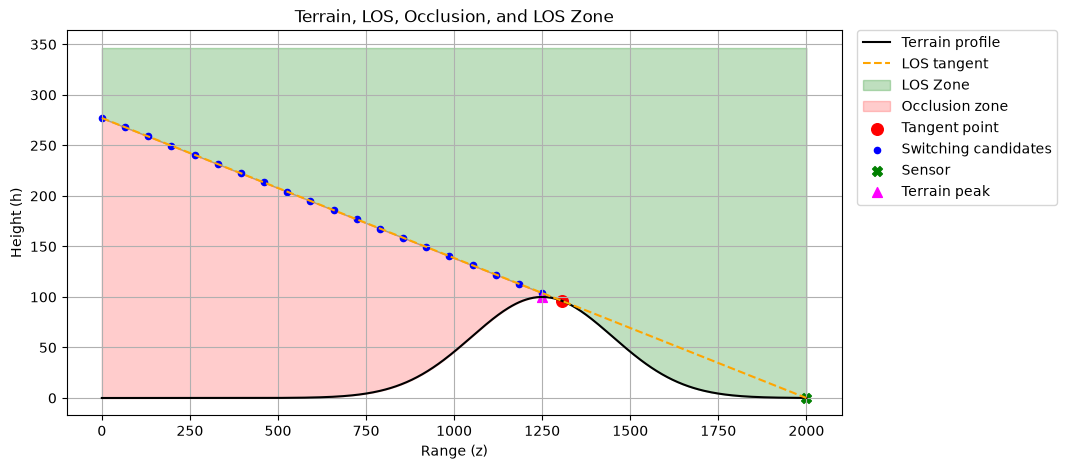

<Figure size 640x480 with 0 Axes>

In [3]:
# STEP 2 PLOT
import matplotlib.pyplot as plt
import numpy as np

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)

z_grid = np.array(terrain_data['z_grid'])
h_terrain_vals = np.array(terrain_data['h_terrain'])
LOS = terrain_data['LOS']
occlusion_mask = np.array(terrain_data['occlusion_mask'], dtype=bool)
los_mask = np.array(terrain_data['los_mask'], dtype=bool)
switching_candidates = np.array(terrain_data['switching_candidates'])

z_sensor = terrain_data['params']['Z_SENSOR']
los_plot_mask = z_grid <= z_sensor
z_line = z_grid[los_plot_mask]
los_line = LOS['slope'] * z_line + LOS['intercept']

y_top = max(h_terrain_vals.max(), los_line.max()) * 1.25
los_line_all = LOS['slope'] * z_grid + LOS['intercept']
los_zone_boundary = np.where(z_grid <= LOS['z_tangent'], los_line_all, h_terrain_vals)

plt.figure(figsize=(10, 5))
plt.plot(z_grid, h_terrain_vals, label='Terrain profile', color='black')
plt.plot(z_line, los_line, '--', label='LOS tangent', color='orange')

# LOS Zone: visible region above LOS line left of tangent and above terrain right of tangent
plt.fill_between(z_grid, los_zone_boundary, y_top, color='green', alpha=0.25, label='LOS Zone')

# Occlusion Zone: terrain < h < LOS line, z < z_tangent
occluded_z = z_grid[occlusion_mask]
occluded_h = h_terrain_vals[occlusion_mask]
h_los_line_occluded = LOS['slope'] * occluded_z + LOS['intercept']
if occluded_z.size > 0:
    plt.fill_between(occluded_z, occluded_h, h_los_line_occluded, color='red', alpha=0.2, label='Occlusion zone')

plt.scatter([LOS['z_tangent']], [LOS['h_tangent']], c='red', s=70, marker='o', label='Tangent point')

plt.scatter(switching_candidates[:, 0], switching_candidates[:, 1], c='blue', s=20, label='Switching candidates')
plt.scatter([terrain_data['params']['Z_SENSOR']], [terrain_data['params']['H_SENSOR']], c='green', s=50, marker='X', label='Sensor')
plt.scatter([terrain_data['params']['Z_RIDGE']], [terrain_data['params']['H_RIDGE']], c='magenta', s=50, marker='^', label='Terrain peak')

plt.xlabel('Range (z)')
plt.ylabel('Height (h)')
plt.title('Terrain, LOS, Occlusion, and LOS Zone')
plt.grid(True)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()
plt.tight_layout()

## Step 3: Sensor Detection Module

This section implements sensor detection models for acoustic, Doppler radar, and RCS radar channels. Detection rates are computed over a (z, h) grid with representative velocity and glide angle values, accounting for occlusion.


In [4]:
# STEP 3 COMPUTE
import numpy as np

def lambda_acoustic(z, h, v, z_sensor, h_sensor, params):
    """
    Acoustic detection rate. Powered phase only.
    λ_ac = LAM_ACOUSTIC * v^N_ACOUSTIC / max(r, R_FLOOR)^2
    r = distance from (z, h) to (z_sensor, h_sensor)
    """
    r = np.sqrt((z - z_sensor)**2 + (h - h_sensor)**2)
    r_eff = np.maximum(r, params['R_FLOOR'])
    lam_ac = params['LAM_ACOUSTIC'] * (v ** params['N_ACOUSTIC']) / (r_eff ** 2)
    return float(lam_ac)


def lambda_doppler(z, h, v, gamma, z_sensor, h_sensor, params):
    """
    Doppler radar detection rate. Both phases.
    λ_dop = LAM_DOPPLER * v_r^2 / max(r, R_FLOOR)^4
    v_r = v * cos(angle between velocity vector and LOS to sensor)
    gamma: glide angle in degrees (negative downward)
    """
    # LOS vector from aircraft to sensor
    dz = z_sensor - z
    dh = h_sensor - h
    r = np.sqrt(dz**2 + dh**2)

    if r < 1e-6:
        return 0.0

    # Velocity vector: v at angle gamma
    gamma_rad = np.radians(gamma)
    v_z = v * np.cos(gamma_rad)
    v_h = v * np.sin(gamma_rad)  # positive upward

    # LOS unit vector
    los_z = dz / r
    los_h = dh / r

    # Radial velocity component
    v_r = v_z * los_z + v_h * los_h

    r_eff = np.maximum(r, params['R_FLOOR'])
    lam_dop = params['LAM_DOPPLER'] * (v_r ** 2) / (r_eff ** 4)
    return float(lam_dop)


def lambda_rcs(z, h, gamma, z_sensor, h_sensor, params):
    """
    RCS radar detection rate. Both phases.
    λ_rcs = LAM_RCS * SIGMA0 * cos^2(gamma - gamma_min) / max(r, R_FLOOR)^4
    """
    r = np.sqrt((z - z_sensor)**2 + (h - h_sensor)**2)
    r_eff = np.maximum(r, params['R_FLOOR'])

    gamma_min = params['GAMMA_MIN']
    angle_diff = gamma - gamma_min
    cos_term = np.cos(np.radians(angle_diff))

    lam_rcs = params['LAM_RCS'] * params['SIGMA0'] * (cos_term ** 2) / (r_eff ** 4)
    return float(lam_rcs)


def lambda_total_fn(z, h, v, gamma, sensor_list, phase, LOS, params):
    """
    Fused detection rate over all sensors and channels.
    phase: 'powered' or 'glide'
    sensor_list: list of (z_s, h_s) tuples
    LOS: dict with 'slope' and 'intercept' defining the LOS line through the
         sensor tangent to the terrain.
    Returns scalar λ_total (sum over sensors and available channels).

    Occlusion: cells below the LOS line are in the ridge shadow and return 0.
    Noise floor: in visible regions, λ_total is lower-bounded by LAM_FLOOR
                 to represent baseline clutter / thermal-noise detection rate.
                 Floor is applied to the total, not per sensor.
    """
    # Occlusion check based on the LOS line.
    h_los_at_z = LOS['slope'] * z + LOS['intercept']
    if (z < LOS['z_tangent']) and (h < h_los_at_z):
        return 0.0

    lam = 0.0
    for z_s, h_s in sensor_list:
        # Acoustic (powered phase only)
        if phase == 'powered':
            lam += lambda_acoustic(z, h, v, z_s, h_s, params)

        # Doppler and RCS (both phases)
        lam += lambda_doppler(z, h, v, gamma, z_s, h_s, params)
        lam += lambda_rcs(z, h, gamma, z_s, h_s, params)

    # Noise floor: applied to total λ in visible region only.
    lam_floor = float(params.get('LAM_FLOOR', 0.0))
    lam = max(lam, lam_floor)

    return float(lam)


# Evaluation on (z, h) grid
z_max = max(params['Z_SENSOR'], params['Z_RIDGE'])
z_grid = np.linspace(0.0, z_max, 50)
h_grid = np.linspace(0.0, params['H_RIDGE'] * 2.0, 50)

# Representative flight parameters
v_powered = 20.0  # m/s, powered phase
v_glide = 15.0    # m/s, glide phase
gamma_powered = -30.0  # degrees
gamma_glide = -45.0    # degrees

# Sensor list (single sensor for now, but scalable)
sensor_list = [(params['Z_SENSOR'], params['H_SENSOR'])]

# Create 2D grids for mapping
Z_grid, H_grid = np.meshgrid(z_grid, h_grid)

# Compute detection maps
lambda_acoustic_map = np.zeros_like(Z_grid)
lambda_doppler_map = np.zeros_like(Z_grid)
lambda_rcs_map = np.zeros_like(Z_grid)
lambda_total_powered_map = np.zeros_like(Z_grid)
lambda_total_glide_map = np.zeros_like(Z_grid)
occlusion_mask_2d = np.zeros_like(Z_grid, dtype=bool)

for i in range(len(h_grid)):
    for j in range(len(z_grid)):
        z, h = Z_grid[i, j], H_grid[i, j]

        # Acoustic (powered only)
        lambda_acoustic_map[i, j] = lambda_acoustic(z, h, v_powered, 
                                                     params['Z_SENSOR'], params['H_SENSOR'], params)

        # Doppler and RCS
        lambda_doppler_map[i, j] = lambda_doppler(z, h, v_powered, gamma_powered,
                                                  params['Z_SENSOR'], params['H_SENSOR'], params)
        lambda_rcs_map[i, j] = lambda_rcs(z, h, gamma_powered,
                                          params['Z_SENSOR'], params['H_SENSOR'], params)

        # Total detection rates
        lambda_total_powered_map[i, j] = lambda_total_fn(z, h, v_powered, gamma_powered, 
                                                      sensor_list, 'powered', LOS, params)
        lambda_total_glide_map[i, j] = lambda_total_fn(z, h, v_glide, gamma_glide,
                                                    sensor_list, 'glide', LOS, params)

        # Occlusion mask for 2D grid
        occlusion_mask_2d[i, j] = z < LOS['z_tangent']

sensor_data = {
    "params": params,
    "z_grid": z_grid.tolist(),
    "h_grid": h_grid.tolist(),
    "lambda_acoustic_map": lambda_acoustic_map.tolist(),
    "lambda_doppler_map": lambda_doppler_map.tolist(),
    "lambda_rcs_map": lambda_rcs_map.tolist(),
    "lambda_total_powered_map": lambda_total_powered_map.tolist(),
    "lambda_total_glide_map": lambda_total_glide_map.tolist(),
    "occlusion_mask_2d": occlusion_mask_2d.tolist(),
    "LOS": LOS,
}

sensor_path = os.path.join(DATA_DIR, 'sensors.json')
with open(sensor_path, 'w') as f:
    json.dump(sensor_data, f, indent=2)

print('Sensor data saved to', sensor_path)


Sensor data saved to d:\git\git_research\glider_hybrid_control\p1b\data\sensors.json


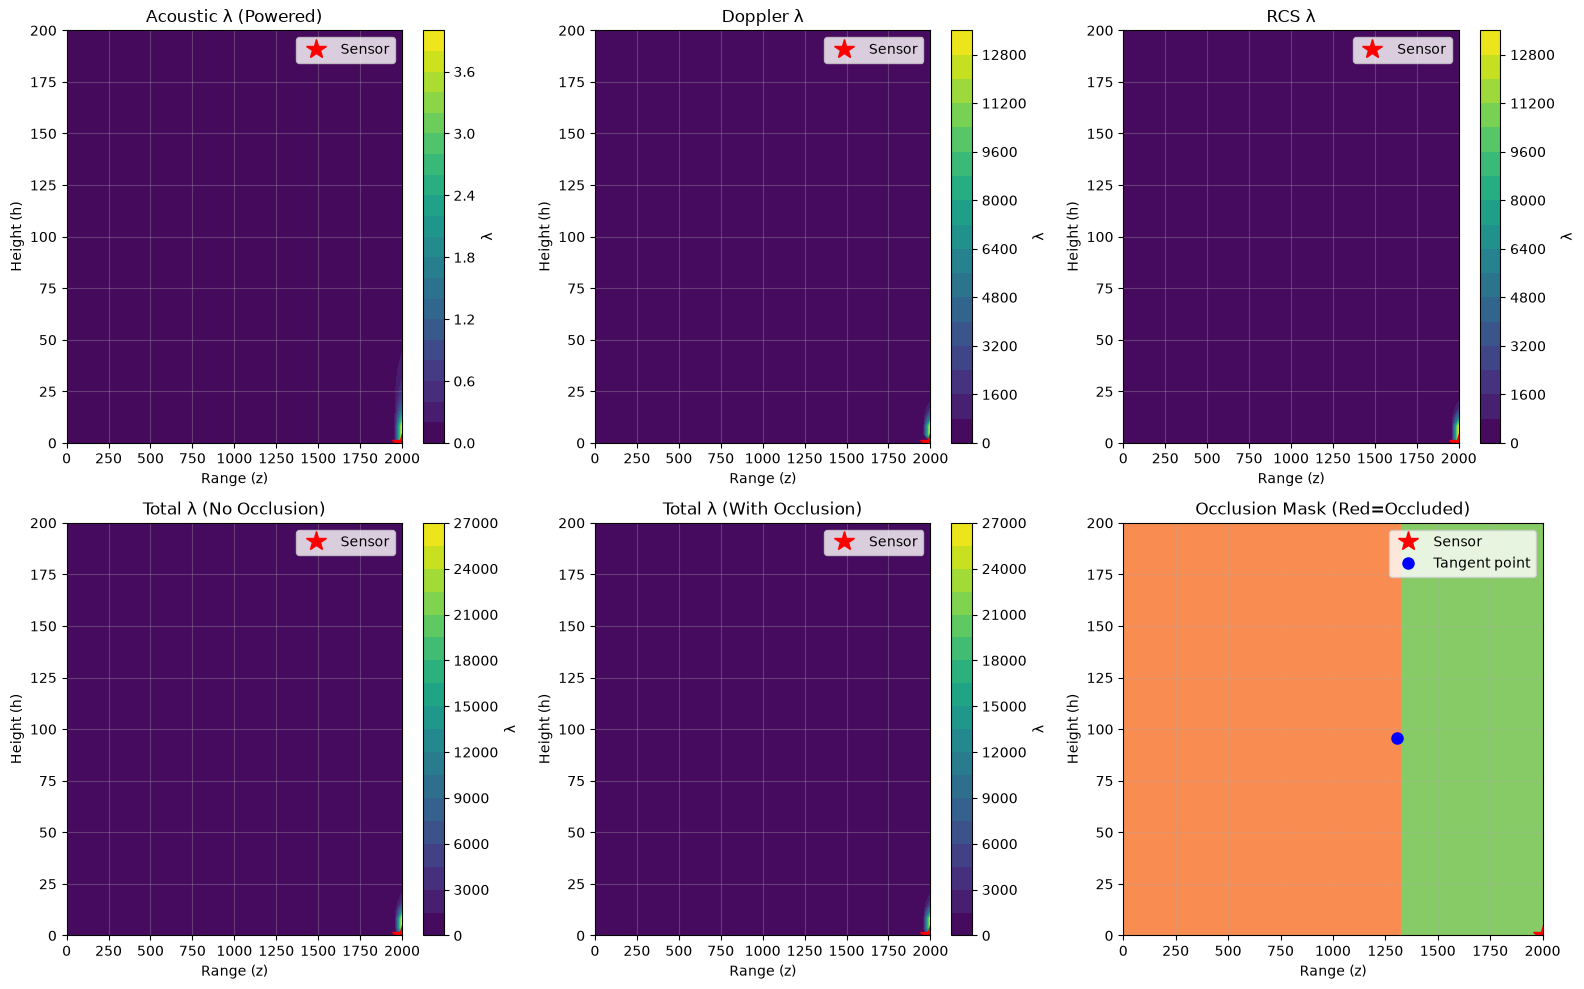

Sensor position: z=2000.0, h=0.0
Max acoustic λ: 3.8400e+00
Max doppler λ: 1.3300e+04
Max RCS λ: 1.3000e+04
Max total λ (no occlusion): 2.6304e+04
Max total λ (with occlusion): 2.6304e+04


In [5]:
# STEP 3 PLOT
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LogNorm
import numpy as np

sensor_path = os.path.join(DATA_DIR, 'sensors.json')
with open(sensor_path, 'r') as f:
    sensor_data = json.load(f)

z_grid = np.array(sensor_data['z_grid'])
h_grid = np.array(sensor_data['h_grid'])
Z_grid, H_grid = np.meshgrid(z_grid, h_grid)

# Use distinct names for arrays to avoid shadowing function names
lambda_acoustic_map = np.array(sensor_data['lambda_acoustic_map'])
lambda_doppler_map = np.array(sensor_data['lambda_doppler_map'])
lambda_rcs_map = np.array(sensor_data['lambda_rcs_map'])
lambda_total_powered_map = np.array(sensor_data['lambda_total_powered_map'])
occlusion_mask_2d = np.array(sensor_data['occlusion_mask_2d'], dtype=bool)

LOS = sensor_data['LOS']
z_sensor = sensor_data['params']['Z_SENSOR']
h_sensor = sensor_data['params']['H_SENSOR']

# Apply occlusion mask: set detection rate to 0 in occlusion zone
lambda_total_powered_occluded = lambda_total_powered_map.copy()
lambda_total_powered_occluded[occlusion_mask_2d] = 0.0

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Helper function to plot heatmap with sensor marker
def plot_detection_map(ax, data, title, z_grid, h_grid, z_sensor, h_sensor):
    im = ax.contourf(Z_grid, H_grid, data, levels=20, cmap='viridis')
    ax.plot([z_sensor], [h_sensor], 'r*', markersize=15, label='Sensor')
    ax.set_xlabel('Range (z)')
    ax.set_ylabel('Height (h)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('λ')
    return im

# Plot each detection channel
plot_detection_map(axes[0, 0], lambda_acoustic_map, 'Acoustic λ (Powered)', z_grid, h_grid, z_sensor, h_sensor)
plot_detection_map(axes[0, 1], lambda_doppler_map, 'Doppler λ', z_grid, h_grid, z_sensor, h_sensor)
plot_detection_map(axes[0, 2], lambda_rcs_map, 'RCS λ', z_grid, h_grid, z_sensor, h_sensor)

# Total detection rate before occlusion
plot_detection_map(axes[1, 0], lambda_total_powered_map, 'Total λ (No Occlusion)', z_grid, h_grid, z_sensor, h_sensor)

# Total detection rate after occlusion
plot_detection_map(axes[1, 1], lambda_total_powered_occluded, 'Total λ (With Occlusion)', z_grid, h_grid, z_sensor, h_sensor)

# Occlusion mask visualization
im_occ = axes[1, 2].contourf(Z_grid, H_grid, occlusion_mask_2d.astype(int), levels=[0, 0.5, 1], cmap='RdYlGn_r')
axes[1, 2].plot([z_sensor], [h_sensor], 'r*', markersize=15, label='Sensor')
axes[1, 2].plot([LOS['z_tangent']], [LOS['h_tangent']], 'bo', markersize=8, label='Tangent point')
axes[1, 2].set_xlabel('Range (z)')
axes[1, 2].set_ylabel('Height (h)')
axes[1, 2].set_title('Occlusion Mask (Red=Occluded)')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print(f"Sensor position: z={z_sensor}, h={h_sensor}")
print(f"Max acoustic λ: {lambda_acoustic_map.max():.4e}")
print(f"Max doppler λ: {lambda_doppler_map.max():.4e}")
print(f"Max RCS λ: {lambda_rcs_map.max():.4e}")
print(f"Max total λ (no occlusion): {lambda_total_powered_map.max():.4e}")
print(f"Max total λ (with occlusion): {lambda_total_powered_occluded.max():.4e}")


## Step 4: Dynamics Module

In [6]:
# STEP 4 COMPUTE
import numpy as np

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)

LOS = terrain_data['LOS']


def powered_trajectory(z_sw, h_sw, params):
    """
    Straight-line kinematics from (0, 0) to (z_sw, h_sw).
    Fixed speed V_LAUNCH, dt = DT_POW.
    Returns list of states: [(z, h, v, gamma), ...]
    """
    v = params['V_LAUNCH']
    dt = params['DT_POW']
    distance = np.sqrt(z_sw**2 + h_sw**2)
    if distance <= 0.0:
        return [(0.0, 0.0, float(v), 0.0)]

    n_steps = max(1, int(np.ceil(distance / (v * dt))))
    z_values = np.linspace(0.0, z_sw, n_steps + 1)
    h_values = np.linspace(0.0, h_sw, n_steps + 1)
    gamma = np.arctan2(h_sw, z_sw)

    return [
        (float(z), float(h), float(v), float(gamma))
        for z, h in zip(z_values, h_values)
    ]


def glider_dynamics(state, gamma_cmd, params):
    """
    Point mass glide dynamics with first-order gamma lag (fixed-wing proxy).
    dv/dt includes the gravity component along the flight path (-g*sin(gamma)):
    diving (gamma<0) trades altitude for speed, climbing/leveling bleeds it via
    drag alone -- so v is now a genuine function of the gamma history flown,
    not of elapsed time alone.
    state: (z, h, v, gamma)
    gamma_cmd: commanded flight path angle (rad) -- a target, not an instant
    setpoint. gamma evolves via gamma_dot = (gamma_cmd - gamma) / TAU_GAMMA,
    so the velocity vector (dz, dh) follows the vehicle's actual attitude,
    not the command. TAU_GAMMA -> 0 recovers the old instant-snap behavior.
    Returns next state after DT_GLIDE. Replaceable interface — do not
    hardcode physics elsewhere. Uses RK4 integration.
    """
    def derivatives(s):
        z, h, v, gamma = s
        dz = v * np.cos(gamma)
        dh = v * np.sin(gamma)
        D = 0.5 * params['RHO'] * v**2 * params['CD'] * params['S']
        dv = -D / params['M'] - params['G'] * np.sin(gamma)
        dgamma = (gamma_cmd - gamma) / params['TAU_GAMMA']
        return np.array([dz, dh, dv, dgamma], dtype=float)

    dt = params['DT_GLIDE']
    s = np.array(state, dtype=float)

    k1 = derivatives(s)
    k2 = derivatives(s + 0.5 * dt * k1)
    k3 = derivatives(s + 0.5 * dt * k2)
    k4 = derivatives(s + dt * k3)

    s_next = s + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0
    s_next[2] = max(s_next[2], 0.0)
    s_next[1] = max(s_next[1], 0.0)

    return (float(s_next[0]), float(s_next[1]), float(s_next[2]), float(s_next[3]))


z_goal = params['Z_GOAL']
h_goal = params['H_GOAL']

# Select switching points strictly on the LOS line and inside the occlusion zone.
z_candidates = np.linspace(0.1 * LOS['z_tangent'], 0.9 * LOS['z_tangent'], 3)

sample_trajectories = []
for idx, z_sw in enumerate(z_candidates):
    h_sw = float(LOS['slope'] * z_sw + LOS['intercept'])
    assert 0.0 < z_sw < LOS['z_tangent'], 'Switch point must remain inside occlusion zone'
    powered = powered_trajectory(z_sw, h_sw, params)

    # Use a constant glide flight path angle that aims from the switch point to the goal.
    gamma_cmd = float(np.arctan2(h_goal - h_sw, z_goal - z_sw))
    glide = []
    state = powered[-1]
    for _ in range(500):
        next_state = glider_dynamics(state, gamma_cmd, params)
        glide.append(next_state)
        if next_state[2] <= 0.0:
            break
        if next_state[0] >= z_goal:
            break
        state = next_state

    if len(glide) > 0 and glide[-1][0] < z_goal and glide[-1][1] > 0.0:
        glide.append((float(z_goal), 0.0, float(glide[-1][2]), float(gamma_cmd)))

    sample_trajectories.append({
        'z_sw': float(z_sw),
        'h_sw': float(h_sw),
        'powered': [[float(x) for x in s] for s in powered],
        'glide': [[float(x) for x in s] for s in glide],
    })

dynamics_data = {
    'params': params,
    'sample_trajectories': sample_trajectories,
}

with open(os.path.join(DATA_DIR, 'dynamics.json'), 'w') as f:
    json.dump(dynamics_data, f, indent=2)

print('Dynamics data saved to', os.path.join(DATA_DIR, 'dynamics.json'))

Dynamics data saved to d:\git\git_research\glider_hybrid_control\p1b\data\dynamics.json


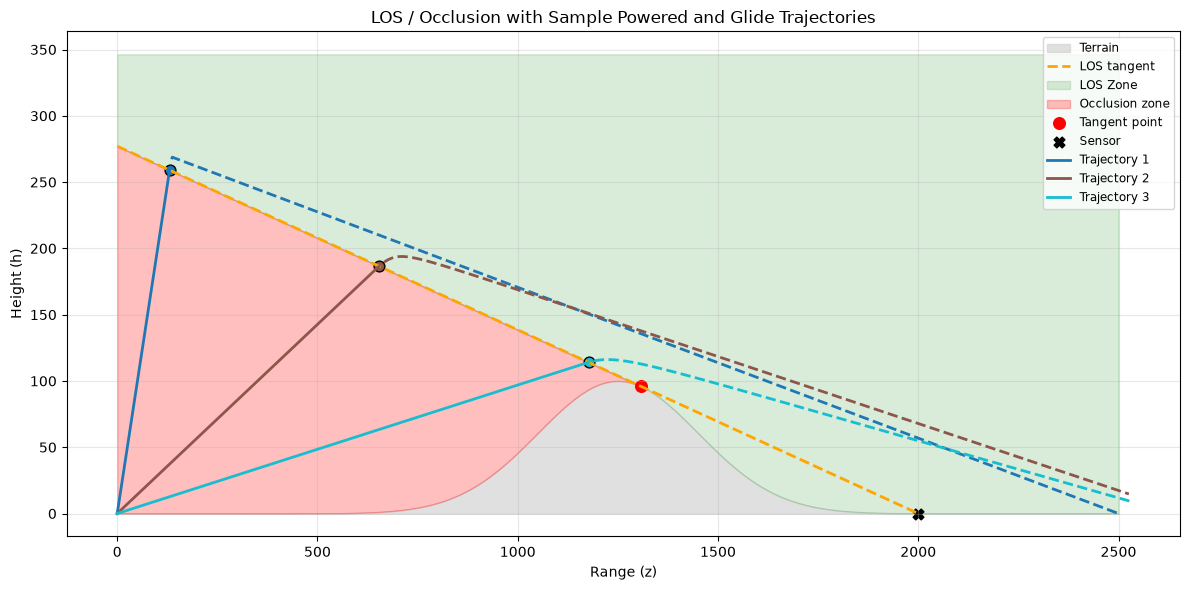

In [7]:
# STEP 4 PLOT
import matplotlib.pyplot as plt
import numpy as np

with open(os.path.join(DATA_DIR, 'terrain.json'), 'r') as f:
    terrain_data = json.load(f)
with open(os.path.join(DATA_DIR, 'dynamics.json'), 'r') as f:
    dynamics_data = json.load(f)

params_plot = terrain_data['params']
LOS = terrain_data['LOS']

# Terrain profile for background.
def h_terrain(z, params):
    z_ridge = params['Z_RIDGE']
    h_ridge = params['H_RIDGE']
    sigma = params['SIGMA_TERRAIN']
    return h_ridge * np.exp(-0.5 * ((z - z_ridge) / sigma) ** 2)

z_grid = np.array(terrain_data['z_grid'])
h_terrain_vals = np.array(terrain_data['h_terrain'])

z_plot = np.linspace(0.0, max(params_plot['Z_SENSOR'], params_plot['Z_GOAL'], params_plot['Z_RIDGE']), 601)
h_plot = h_terrain(z_plot, params_plot)
los_mask_plot = z_plot <= params_plot['Z_SENSOR']
z_line = z_plot[los_mask_plot]
los_line = LOS['slope'] * z_line + LOS['intercept']

y_top = max(h_plot.max(), np.max(los_line)) * 1.25
los_line_all = LOS['slope'] * z_plot + LOS['intercept']
los_zone_boundary = np.where(z_plot <= LOS['z_tangent'], los_line_all, h_plot)

plt.figure(figsize=(12, 6))
plt.fill_between(z_plot, 0.0, h_plot, color='lightgrey', alpha=0.7, label='Terrain')
plt.plot(z_line, los_line, '--', color='orange', linewidth=2, label='LOS tangent')
plt.fill_between(z_plot, los_zone_boundary, y_top, color='green', alpha=0.15, label='LOS Zone')

occlusion_mask = np.array(terrain_data['occlusion_mask'], dtype=bool)
occluded_z = z_grid[occlusion_mask]
occluded_h = h_terrain_vals[occlusion_mask]
h_los_line_occluded = LOS['slope'] * occluded_z + LOS['intercept']
if occluded_z.size > 0:
    plt.fill_between(occluded_z, occluded_h, h_los_line_occluded, color='red', alpha=0.25, label='Occlusion zone')

plt.scatter([LOS['z_tangent']], [LOS['h_tangent']], c='red', s=70, marker='o', label='Tangent point')
plt.scatter([params_plot['Z_SENSOR']], [params_plot['H_SENSOR']], c='black', s=60, marker='X', label='Sensor')

colors = plt.cm.tab10(np.linspace(0, 1, len(dynamics_data['sample_trajectories'])))
for idx, traj in enumerate(dynamics_data['sample_trajectories']):
    powered = np.array(traj['powered'])
    glide = np.array(traj['glide'])
    z_sw = traj['z_sw']
    h_sw = traj['h_sw']
    color = colors[idx]

    trajectory_label = f'Trajectory {idx + 1}'

    plt.plot(powered[:, 0], powered[:, 1], '-', linewidth=2, color=color, label=trajectory_label)
    if glide.size > 0:
        plt.plot(glide[:, 0], glide[:, 1], '--', linewidth=2, color=color, label='_nolegend_')
    plt.scatter([z_sw], [h_sw], s=60, c=[color], edgecolors='k', linewidths=1.0, marker='o', label='_nolegend_')

plt.xlabel('Range (z)')
plt.ylabel('Height (h)')
plt.title('LOS / Occlusion with Sample Powered and Glide Trajectories')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize='small')
plt.tight_layout()
plt.show()

## Step 5: 4D Stage Cost Table

Build the 4D instantaneous stage cost table `c_4D[iz, ih, iv, ig]` over `(z, h, v, γ)`. No optimization, no DP. Stage cost is `1 - exp(-λ_total(state) * DT_DP)` for the glide phase. Terrain validity is recorded separately as a 2D boolean mask since it does not depend on `(v, γ)`. Saved to `data/stage_cost_4d.json` and consumed by Step 6.

In [8]:
# STEP 5 COMPUTE — 4D Stage Cost Table
import numpy as np
import math

# Load dependencies from earlier steps
terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)
LOS = terrain_data['LOS']

sensor_list = [(params['Z_SENSOR'], params['H_SENSOR'])]


def build_state_grid(params):
    """
    Build 4D grid over (z, h, v, gamma).
    Returns 1D arrays. Scalable: increase N_V later to make v an action.
    """
    N_Z = int(params['N_Z'])
    N_H = int(params['N_H'])
    N_V = int(params['N_V'])
    gamma_min_deg = float(params['GAMMA_MIN'])
    gamma_max_deg = float(params['GAMMA_MAX'])
    d_gamma = float(params['D_GAMMA'])
    N_GAMMA = int(round((gamma_max_deg - gamma_min_deg) / d_gamma)) + 1

    z_grid = np.linspace(0.0, float(params['Z_GOAL']), N_Z)
    # h_max = max(2.0 * float(params['H_RIDGE']), 50.0)
    # h_grid = np.linspace(0.0, h_max, N_H)
    h_grid = np.linspace(0.0, float(params['H_MAX_GRID']), N_H)


    if N_V == 1:
        v_grid = np.array([float(params['V_STALL'])])
    else:
        v_grid = np.linspace(float(params['V_STALL']), float(params['V_MAX']), N_V)

    gamma_grid = np.linspace(gamma_min_deg, gamma_max_deg, N_GAMMA)
    return z_grid, h_grid, v_grid, gamma_grid


def build_terrain_mask_2d(z_grid, h_grid, params):
    """
    terrain_mask[iz, ih] = True if (z, h) is below terrain surface (invalid).
    2D only — terrain validity does not depend on (v, gamma).
    Strict < so ground level (h=0 where h_terrain=0) is treated as valid.
    """
    TERRAIN_EPS = 1e-3  # numerical tolerance for ground level
    NZ, NH = len(z_grid), len(h_grid)
    mask = np.zeros((NZ, NH), dtype=bool)
    for iz, z in enumerate(z_grid):
        h_t = float(h_terrain(z, params))
        for ih, h in enumerate(h_grid):
            mask[iz, ih] = (h_t > TERRAIN_EPS) and (h < h_t)
    return mask


def build_stage_cost_4d(z_grid, h_grid, v_grid, gamma_grid, sensor_list, LOS, params):
    """
    c_4D[iz, ih, iv, ig] = 1 - exp(-lambda_total * DT_DP) for the glide phase.

    Pure evaluation of instantaneous stage cost on the 4D grid.
    No DP, no min/max. gamma stays as a free axis for Step 6 DP to optimize over.
    """
    NZ, NH = len(z_grid), len(h_grid)
    NV, NG = len(v_grid), len(gamma_grid)
    c_4D = np.zeros((NZ, NH, NV, NG), dtype=float)
    dt = float(params['DT_DP'])

    for iz in range(NZ):
        z = float(z_grid[iz])
        for ih in range(NH):
            h = float(h_grid[ih])
            for iv in range(NV):
                v = float(v_grid[iv])
                for ig in range(NG):
                    gamma_deg = float(gamma_grid[ig])
                    lam = lambda_total_fn(
                        z, h, v, gamma_deg,
                        sensor_list, 'glide', LOS, params
                    )
                    c_4D[iz, ih, iv, ig] = 1.0 - math.exp(-lam * dt)
    return c_4D


# Build everything
z_grid, h_grid, v_grid, gamma_grid = build_state_grid(params)
terrain_mask_2d = build_terrain_mask_2d(z_grid, h_grid, params)
c_4D = build_stage_cost_4d(z_grid, h_grid, v_grid, gamma_grid,
                            sensor_list, LOS, params)

print(f'Grid: NZ={len(z_grid)}, NH={len(h_grid)}, NV={len(v_grid)}, NG={len(gamma_grid)}')
print(f'c_4D shape: {c_4D.shape}')
print(f'c_4D range: [{c_4D.min():.4e}, {c_4D.max():.4e}]')
print(f'terrain-invalid cells (2D): {int(terrain_mask_2d.sum())} / {terrain_mask_2d.size}')

stage_cost_data = {
    'params': params,
    'z_grid': z_grid.tolist(),
    'h_grid': h_grid.tolist(),
    'v_grid': v_grid.tolist(),
    'gamma_grid': gamma_grid.tolist(),
    'c_4D': c_4D.tolist(),
    'terrain_mask_2d': terrain_mask_2d.tolist(),
}

stage_cost_path = os.path.join(DATA_DIR, 'stage_cost_4d.json')
with open(stage_cost_path, 'w') as f:
    json.dump(stage_cost_data, f, indent=2)
print('Stage cost table saved to', stage_cost_path)

Grid: NZ=250, NH=250, NV=1, NG=19
c_4D shape: (250, 250, 1, 19)
c_4D range: [0.0000e+00, 1.0000e+00]
terrain-invalid cells (2D): 6338 / 62500


Stage cost table saved to d:\git\git_research\glider_hybrid_control\p1b\data\stage_cost_4d.json


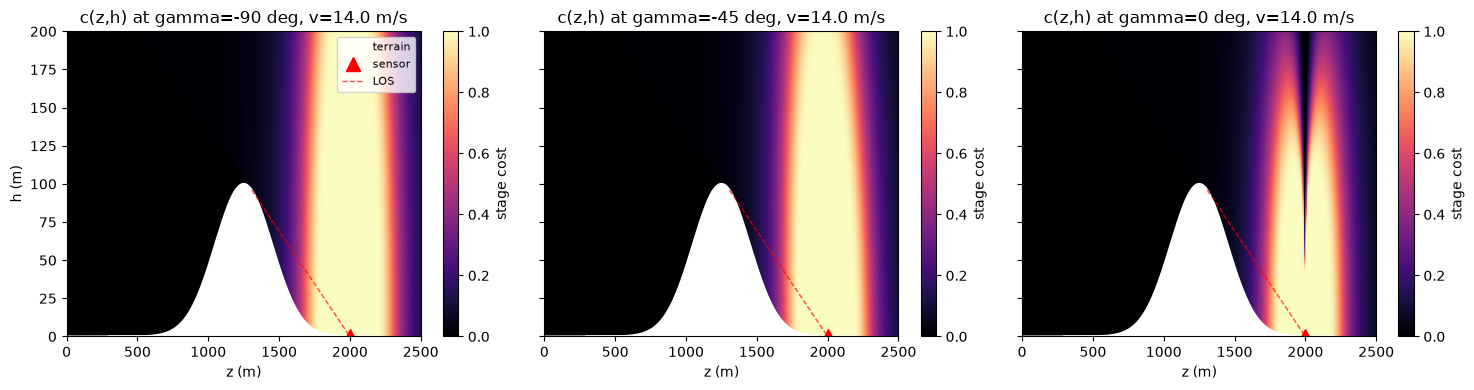

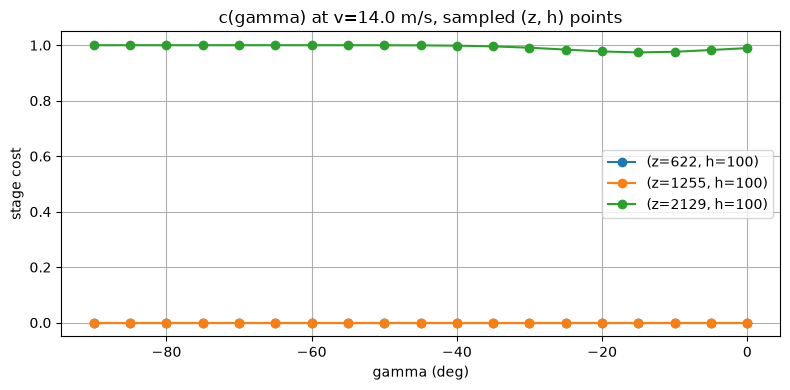

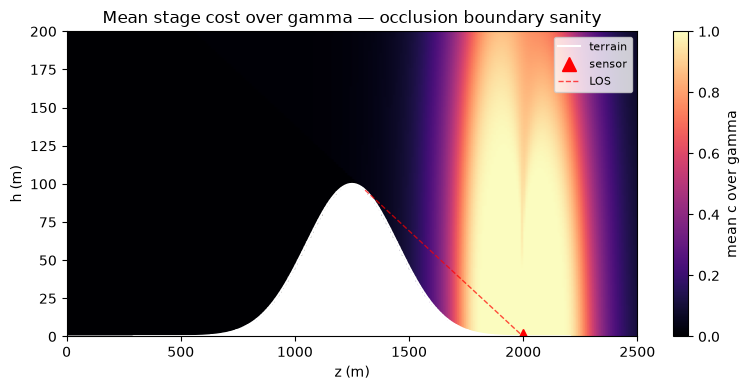

In [9]:
# STEP 5 PLOT — Stage Cost Table Visualization (load stage_cost_4d.json, no recompute)
import matplotlib.pyplot as plt
import numpy as np

stage_cost_path = os.path.join(DATA_DIR, 'stage_cost_4d.json')
with open(stage_cost_path, 'r') as f:
    sc = json.load(f)

z_grid = np.array(sc['z_grid'])
h_grid = np.array(sc['h_grid'])
v_grid = np.array(sc['v_grid'])
gamma_grid = np.array(sc['gamma_grid'])
c_4D = np.array(sc['c_4D'])
terrain_mask_2d = np.array(sc['terrain_mask_2d'])

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)
z_terrain = np.array(terrain_data['z_grid'])
h_terrain_vals = np.array(terrain_data['h_terrain'])
LOS = terrain_data['LOS']


def mask_terrain(c_2d):
    out = c_2d.copy()
    out[terrain_mask_2d] = np.nan
    return out


def overlay(ax):
    ax.plot(z_terrain, h_terrain_vals, 'w-', lw=1.5, label='terrain')
    ax.plot(params['Z_SENSOR'], params['H_SENSOR'], 'r^',
            markersize=10, label='sensor')
    z_los = np.linspace(LOS['z_tangent'], params['Z_SENSOR'], 50)
    h_los = LOS['slope'] * z_los + LOS['intercept']
    ax.plot(z_los, h_los, 'r--', lw=1, alpha=0.7, label='LOS')


# --- Plot 1: c(z, h) heatmap at gamma slices, v fixed ---
iv = 0
gamma_slice_indices = [0, len(gamma_grid)//2, len(gamma_grid)-1]

fig, axes = plt.subplots(1, len(gamma_slice_indices), figsize=(15, 4), sharey=True)
for ax, ig in zip(axes, gamma_slice_indices):
    c_zh_masked = mask_terrain(c_4D[:, :, iv, ig])
    im = ax.imshow(
        c_zh_masked.T, origin='lower',
        extent=(z_grid[0], z_grid[-1], h_grid[0], h_grid[-1]),
        aspect='auto', cmap='magma',
    )
    overlay(ax)
    ax.set_xlabel('z (m)')
    ax.set_title(f'c(z,h) at gamma={gamma_grid[ig]:.0f} deg, v={v_grid[iv]:.1f} m/s')
    fig.colorbar(im, ax=ax, label='stage cost')
axes[0].set_ylabel('h (m)')
axes[0].legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

# --- Plot 2: c(gamma) curves at representative (z, h) points ---
sample_points_idx = [
    (len(z_grid)//4,        len(h_grid)//2),   # left, occluded
    (len(z_grid)//2,        len(h_grid)//2),   # mid
    (int(0.85*len(z_grid)), len(h_grid)//2),   # near goal, exposed
]

plt.figure(figsize=(8, 4))
for iz, ih in sample_points_idx:
    plt.plot(gamma_grid, c_4D[iz, ih, 0, :], marker='o',
             label=f'(z={z_grid[iz]:.0f}, h={h_grid[ih]:.0f})')
plt.xlabel('gamma (deg)')
plt.ylabel('stage cost')
plt.title(f'c(gamma) at v={v_grid[0]:.1f} m/s, sampled (z, h) points')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 3: occlusion boundary sanity ---
c_mean_over_gamma = c_4D[:, :, 0, :].mean(axis=-1)
c_mean_masked = mask_terrain(c_mean_over_gamma)

plt.figure(figsize=(8, 4))
im = plt.imshow(
    c_mean_masked.T, origin='lower',
    extent=(z_grid[0], z_grid[-1], h_grid[0], h_grid[-1]),
    aspect='auto', cmap='magma',
)
plt.colorbar(im, label='mean c over gamma')
overlay(plt.gca())
plt.xlabel('z (m)')
plt.ylabel('h (m)')
plt.title('Mean stage cost over gamma — occlusion boundary sanity')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
# 적용 후 검증용 한 줄
print(f'min in visible region: {c_4D[c_4D > 0].min():.4f}')   # ≈ 0.01 (floor)
print(f'max: {c_4D.max():.4f}')                                # ≈ 1.0 (saturated)

min in visible region: 0.0100
max: 1.0000


## Step 6: Cost-to-Go Map + Optimal Path Extraction

Step 6-1 builds the cost-to-go map over the state space `(z, h, v, gamma)`. Both `v`
and `gamma` are real discretized state dimensions: `glider_dynamics`' `dv/dt` includes
the gravity component along the flight path (`-g*sin(gamma)`), so a steep dive
genuinely trades altitude for speed (offset by drag), and `v` -- like `gamma` --
depends on the whole history of commands flown, not on elapsed time alone. (An
earlier version of this map tried to avoid a `v` state dimension by noting that a
drag-only `dv/dt` is policy-independent and indexing `v` off a stage-count clock
instead -- that simplification became invalid once the gravity term was added back
in, since `v` now genuinely branches by which `gamma` actions were taken.)

The edge weight for action `ig` out of a state is the lag-aware integrated cost of
actually flying that action for one stage from that state -- not a best-case
projection, not a static constant-gamma lookup. This propagation is a priority-queue
relaxation (Dijkstra's algorithm) from every `(v, gamma)` at the goal column.
Resolution (`NV_STATE=9`, `NG_STATE=7`) is deliberately reduced for this first
measurement; a literature review for a more efficient method is planned before
scaling up.

Step 6-2 extracts the optimal path and policy from this map by walking forward from a
starting state to the goal.

In [11]:
# STEP 6-1 COMPUTE — Cost-to-Go Map over (z, h, v, gamma) state space
import heapq
import math
import numpy as np

stage_cost_path = os.path.join(DATA_DIR, 'stage_cost_4d.json')
with open(stage_cost_path, 'r') as f:
    sc = json.load(f)

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)
LOS = terrain_data['LOS']
sensor_list = [(params['Z_SENSOR'], params['H_SENSOR'])]

z_grid = np.array(sc['z_grid'])
h_grid = np.array(sc['h_grid'])
gamma_grid = np.array(sc['gamma_grid'])  # action grid (commanded gamma choices)
c_4D = np.array(sc['c_4D'])
terrain_mask_2d = np.array(sc['terrain_mask_2d'], dtype=bool)
NZ, NH, NG = len(z_grid), len(h_grid), len(gamma_grid)
z_step = float(z_grid[1] - z_grid[0])

# --- v is real state again ---
#
# glider_dynamics' dv/dt now includes the gravity component along the flight
# path (-g*sin(gamma)): diving trades altitude for speed, so v depends on the
# entire gamma history flown, not on elapsed time alone. The [5]+[6]
# simplification (v as a time-indexed decay curve, shared by every policy)
# relied on dv/dt depending only on v -- that's no longer true, so v is
# promoted back to a genuine discretized state dimension (v_state_grid),
# replacing the stage-index clock k (which only ever existed to look up v).
#
# gamma remains a real state dimension too (gamma_state_grid), separate from
# the action grid (gamma_grid, the commanded target each stage) -- unchanged
# from [6].
NV_STATE = 9
NG_STATE = 7
v_state_grid = np.linspace(2.0, float(params['V_MAX']), NV_STATE)
gamma_state_grid = np.linspace(-90.0, 0.0, NG_STATE)
n_sub = int(round(params['DT_DP'] / params['DT_GLIDE']))
dt = params['DT_GLIDE']


def project_2d(c_4D):
    """
    c_2D[iz, ih] = min over (iv, ig) of c_4D[iz, ih, iv, ig]. Best-case
    instantaneous stage cost at a cell -- reference/lower bound for
    plotting only, not used as an edge weight anywhere in this notebook.
    """
    NZc, NHc, NV, NGc = c_4D.shape
    c_flat = c_4D.reshape(NZc, NHc, NV * NGc)
    return np.min(c_flat, axis=-1)


c_2D = project_2d(c_4D)

# Occlusion mask: same condition as is_occluded (Step 2), vectorized over the
# (z, h) grid. The propagation below is restricted to the LOS zone only —
# the occlusion zone is excluded from the graph entirely, same as terrain.
Z_grid, H_grid = np.meshgrid(z_grid, h_grid, indexing='ij')
h_los_at_z = LOS['slope'] * Z_grid + LOS['intercept']
occlusion_mask_2d = (Z_grid < LOS['z_tangent']) & (H_grid < h_los_at_z)
exclude_mask = terrain_mask_2d | occlusion_mask_2d


def nearest_idx(grid, val):
    """Return index in grid closest to val. Assumes grid is uniformly spaced."""
    step = grid[1] - grid[0]
    idx = int(round((val - grid[0]) / step))
    return int(np.clip(idx, 0, len(grid) - 1))


def nearest_idx_vec(grid, vals):
    """Vectorized nearest_idx for an array of values."""
    step = grid[1] - grid[0]
    idx = np.round((vals - grid[0]) / step).astype(int)
    return np.clip(idx, 0, len(grid) - 1)


def build_state_transition_tables(v_state_grid, gamma_state_grid, gamma_action_grid, h_grid, params):
    """
    For each (starting v_state, gamma_state, action), propagate one DT_DP
    stage with the real (gravity-corrected) dynamics. Position result
    (dz, h_next) and the resulting (v, gamma) are independent of (z, h) --
    same translation-invariance trick as before -- so this is a small
    (NV_STATE, NG_STATE, NG_action) sweep, not a full grid sweep.
    """
    NV_s, NG_s, NG_a = len(v_state_grid), len(gamma_state_grid), len(gamma_action_grid)
    h_ref0 = float(h_grid.max() + params['V_MAX'] * params['DT_DP'] * 2.0 + 10.0)
    dz_table = np.zeros((NV_s, NG_s, NG_a))
    v_next_table = np.zeros((NV_s, NG_s, NG_a))
    gamma_next_table = np.zeros((NV_s, NG_s, NG_a))
    h_next_table = np.zeros((NV_s, NG_s, NG_a, len(h_grid)))
    for iv_s, v0 in enumerate(v_state_grid):
        for ig_s, gamma_s_deg in enumerate(gamma_state_grid):
            for ig_a, gamma_a_deg in enumerate(gamma_action_grid):
                gamma_a_rad = float(np.radians(gamma_a_deg))
                state = (0.0, h_ref0, float(v0), float(np.radians(gamma_s_deg)))
                h_prev = h_ref0
                h_arr = h_grid.copy()
                for _ in range(n_sub):
                    state = glider_dynamics(state, gamma_a_rad, params)
                    dh_step = state[1] - h_prev
                    h_prev = state[1]
                    h_arr = np.maximum(h_arr + dh_step, 0.0)
                dz_table[iv_s, ig_s, ig_a] = state[0]
                v_next_table[iv_s, ig_s, ig_a] = state[2]
                gamma_next_table[iv_s, ig_s, ig_a] = float(np.degrees(state[3]))
                h_next_table[iv_s, ig_s, ig_a] = h_arr
    return dz_table, v_next_table, gamma_next_table, h_next_table


dz_table, v_next_table, gamma_next_table, h_next_table = build_state_transition_tables(
    v_state_grid, gamma_state_grid, gamma_grid, h_grid, params)
diz_table = np.round(dz_table / z_step).astype(int)
iv_next_table = np.array([
    [[nearest_idx(v_state_grid, v_next_table[iv_s, ig_s, ig_a]) for ig_a in range(NG)]
     for ig_s in range(NG_STATE)] for iv_s in range(NV_STATE)
])
ig_s_next_table = np.array([
    [[nearest_idx(gamma_state_grid, gamma_next_table[iv_s, ig_s, ig_a]) for ig_a in range(NG)]
     for ig_s in range(NG_STATE)] for iv_s in range(NV_STATE)
])
ih_next_idx_table = np.array([
    [[nearest_idx_vec(h_grid, h_next_table[iv_s, ig_s, ig_a]) for ig_a in range(NG)]
     for ig_s in range(NG_STATE)] for iv_s in range(NV_STATE)
])
print('state-transition tables built')

# --- Cost sweep: integrate the actual detection rate along each
# (cell, v_state, gamma_state, action) substep trajectory, with v evolving
# under the real (gravity-corrected) dynamics. This does NOT have
# translation invariance over z (sensor distance is absolute), so it is a
# full (NZ, NH, NV_STATE, NG_STATE, NG) sweep -- the expensive part; cached
# to disk so later cells/runs can skip it. ---
cache_path = os.path.join(DATA_DIR, f'c_lagged_5d_v2_cache_{NZ}x{NH}.npz')  # resolution-tagged so different grid sizes don't collide
if os.path.exists(cache_path):
    c_lagged = np.load(cache_path)['c_lagged']
    print('loaded cached c_lagged, shape', c_lagged.shape)
else:
    import time
    t0 = time.time()
    c_lagged = np.zeros((NZ, NH, NV_STATE, NG_STATE, NG))
    for iz in range(NZ):
        z0 = float(z_grid[iz])
        for ih in range(NH):
            if exclude_mask[iz, ih]:
                continue
            h0 = float(h_grid[ih])
            for iv_s, v0 in enumerate(v_state_grid):
                for ig_s in range(NG_STATE):
                    gamma_s_rad = float(np.radians(gamma_state_grid[ig_s]))
                    for ig_a in range(NG):
                        gamma_a_rad = float(np.radians(gamma_grid[ig_a]))
                        state = (z0, h0, float(v0), gamma_s_rad)
                        lam_sum = 0.0
                        for _ in range(n_sub):
                            state = glider_dynamics(state, gamma_a_rad, params)
                            z, h, v, gr = state
                            lam_sum += lambda_total_fn(
                                z, h, v, float(np.degrees(gr)),
                                sensor_list, 'glide', LOS, params
                            )
                        c_lagged[iz, ih, iv_s, ig_s, ig_a] = 1.0 - math.exp(-lam_sum * dt)
        if iz % 25 == 0:
            print(f'  cost sweep iz={iz}/{NZ}, elapsed={time.time() - t0:.0f}s')
    print(f'cost sweep done in {time.time() - t0:.0f}s')
    np.savez_compressed(cache_path, c_lagged=c_lagged)
    print('cached to', cache_path)

print(f'c_lagged range: [{c_lagged.min():.4e}, {c_lagged.max():.4e}]')


def flat(iz, ih, iv_s, ig_s):
    return ((iz * NH + ih) * NV_STATE + iv_s) * NG_STATE + ig_s


N_STATES = NZ * NH * NV_STATE * NG_STATE

# Reverse graph over the full (z, h, v_state, gamma_state) state space.
# rev_adj[dst] = [(src, weight, action), ...]
rev_adj = {}
for iz in range(NZ):
    for ih in range(NH):
        if exclude_mask[iz, ih]:
            continue
        for iv_s in range(NV_STATE):
            for ig_s in range(NG_STATE):
                src = flat(iz, ih, iv_s, ig_s)
                for ig_a in range(NG):
                    iz_n = int(np.clip(iz + diz_table[iv_s, ig_s, ig_a], 0, NZ - 1))
                    ih_n = int(ih_next_idx_table[iv_s, ig_s, ig_a, ih])
                    if exclude_mask[iz_n, ih_n]:
                        continue
                    iv_s_n = int(iv_next_table[iv_s, ig_s, ig_a])
                    ig_s_n = int(ig_s_next_table[iv_s, ig_s, ig_a])
                    dst = flat(iz_n, ih_n, iv_s_n, ig_s_n)
                    weight = float(c_lagged[iz, ih, iv_s, ig_s, ig_a])
                    rev_adj.setdefault(dst, []).append((src, weight, ig_a))

iz_goal = NZ - 1
ih_goal = nearest_idx(h_grid, params['H_GOAL'])

# Multi-source Dijkstra: every (v_state, gamma_state) at the goal column is a
# valid goal (cost 0) -- reaching (Z_GOAL, H_GOAL) is what matters, regardless
# of the vehicle's final speed or attitude.
dist = np.full(N_STATES, np.inf)
predecessor = np.full(N_STATES, -1, dtype=np.int64)
predecessor_action = np.full(N_STATES, -1, dtype=np.int32)
visited = np.zeros(N_STATES, dtype=bool)
heap = []
for iv_s in range(NV_STATE):
    for ig_s in range(NG_STATE):
        gf = flat(iz_goal, ih_goal, iv_s, ig_s)
        dist[gf] = 0.0
        heap.append((0.0, gf))
heapq.heapify(heap)

while heap:
    d, u = heapq.heappop(heap)
    if visited[u]:
        continue
    visited[u] = True
    for v, w, ig in rev_adj.get(u, []):
        nd = d + w
        if nd < dist[v]:
            dist[v] = nd
            predecessor[v] = u
            predecessor_action[v] = ig
            heapq.heappush(heap, (nd, v))

finite_dist = dist[np.isfinite(dist)]
print(f'dist range (finite): [{finite_dist.min():.4f}, {finite_dist.max():.4f}]')

# Canonical (v_state, gamma_state) = (V_STALL, level) slice of J for the
# Step 6-1 heatmap plot, matching "freshly entering the LOS zone at stall
# speed, level attitude" -- the same condition every switching candidate
# enters at in Step 6-2.
iv_s0 = nearest_idx(v_state_grid, params['V_STALL'])
ig_s0 = nearest_idx(gamma_state_grid, 0.0)
J_2D = np.full((NZ, NH), np.inf)
for iz in range(NZ):
    for ih in range(NH):
        if not exclude_mask[iz, ih]:
            J_2D[iz, ih] = dist[flat(iz, ih, iv_s0, ig_s0)]

costmap_data = {
    'params': sc['params'],
    'z_grid': z_grid.tolist(),
    'h_grid': h_grid.tolist(),
    'gamma_grid': gamma_grid.tolist(),
    'v_state_grid': v_state_grid.tolist(),
    'gamma_state_grid': gamma_state_grid.tolist(),
    'c_2D': c_2D.tolist(),
    'terrain_mask_2d': terrain_mask_2d.tolist(),
    'occlusion_mask_2d': occlusion_mask_2d.tolist(),
    'exclude_mask_2d': exclude_mask.tolist(),
    'J_2D': J_2D.tolist(),
    'goal_cell': [iz_goal, ih_goal],
    'state_shape': [NZ, NH, NV_STATE, NG_STATE],
    'canonical_state': [iv_s0, ig_s0],
}
costmap_path = os.path.join(DATA_DIR, 'costmap_2d.json')
with open(costmap_path, 'w') as f:
    json.dump(costmap_data, f, indent=2)

state_path = os.path.join(DATA_DIR, 'costmap_4d_state.npz')
np.savez_compressed(
    state_path,
    dist=dist, predecessor=predecessor, predecessor_action=predecessor_action,
)
print('Cost-to-go map saved to', costmap_path, 'and', state_path)

state-transition tables built
  cost sweep iz=0/250, elapsed=0s
  cost sweep iz=25/250, elapsed=0s
  cost sweep iz=50/250, elapsed=0s


  cost sweep iz=75/250, elapsed=131s


  cost sweep iz=100/250, elapsed=677s


  cost sweep iz=125/250, elapsed=1648s


  cost sweep iz=150/250, elapsed=3245s


...

  cost sweep iz=225/250, elapsed=12242s


cost sweep done in 15484s


cached to d:\git\git_research\glider_hybrid_control\p1b\data\c_lagged_5d_v2_cache_250x250.npz
c_lagged range: [0.0000e+00, 1.0000e+00]


dist range (finite): [0.0000, 2.0000]


Cost-to-go map saved to d:\git\git_research\glider_hybrid_control\p1b\data\costmap_2d.json and d:\git\git_research\glider_hybrid_control\p1b\data\costmap_4d_state.npz


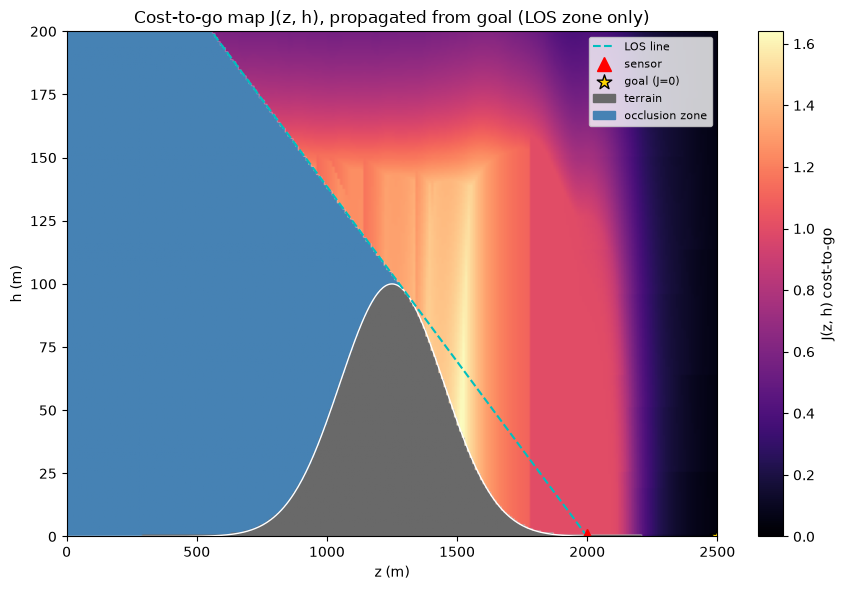

In [12]:
# STEP 6-1 PLOT — Cost-to-Go Map (load costmap_2d.json, no recompute)
#
# Single (z, h) heatmap of J(z, h): the goal cell (Z_GOAL, H_GOAL) is cost 0,
# and cost accumulates outward as cells require more stage cost to reach the
# goal. Terrain (gray) and the occlusion zone (steel blue, excluded from the
# Dijkstra graph since this map covers the LOS zone only) are drawn as flat
# background colors so they read as distinct regions rather than both NaN.
# Terrain is drawn last so it takes precedence where the ridge itself falls
# inside the occlusion zone (z < z_tangent).
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

costmap_path = os.path.join(DATA_DIR, 'costmap_2d.json')
with open(costmap_path, 'r') as f:
    cm = json.load(f)

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)

z_grid = np.array(cm['z_grid'])
h_grid = np.array(cm['h_grid'])
J_2D = np.array(cm['J_2D'])
terrain_mask_2d = np.array(cm['terrain_mask_2d'], dtype=bool)
occlusion_mask_2d = np.array(cm['occlusion_mask_2d'], dtype=bool)
exclude_mask = np.array(cm['exclude_mask_2d'], dtype=bool)

z_terrain = np.array(terrain_data['z_grid'])
h_terrain_vals = np.array(terrain_data['h_terrain'])
LOS = terrain_data['LOS']

TERRAIN_COLOR = 'dimgray'
OCCLUSION_COLOR = 'steelblue'

background = np.zeros((len(z_grid), len(h_grid), 4))
background[occlusion_mask_2d] = mcolors.to_rgba(OCCLUSION_COLOR)
background[terrain_mask_2d] = mcolors.to_rgba(TERRAIN_COLOR)

J_plot = np.where(np.isfinite(J_2D) & ~exclude_mask, J_2D, np.nan)
cmap = plt.get_cmap('magma').copy()
cmap.set_bad(color=(1, 1, 1, 0))

extent = (z_grid[0], z_grid[-1], h_grid[0], h_grid[-1])
plt.figure(figsize=(9, 6))
plt.imshow(np.transpose(background, (1, 0, 2)), origin='lower', extent=extent, aspect='auto')
im = plt.imshow(J_plot.T, origin='lower', extent=extent, aspect='auto', cmap=cmap)
plt.colorbar(im, label='J(z, h) cost-to-go')

plt.plot(z_terrain, h_terrain_vals, 'w-', lw=1.0)
los_line = LOS['slope'] * z_grid + LOS['intercept']
plt.plot(z_grid, los_line, 'c--', lw=1.5, label='LOS line')
plt.plot(params['Z_SENSOR'], params['H_SENSOR'], 'r^', markersize=10, label='sensor')
plt.scatter([params['Z_GOAL']], [params['H_GOAL']], c='gold', s=120, marker='*', edgecolors='k', label='goal (J=0)')

legend_handles, legend_labels = plt.gca().get_legend_handles_labels()
legend_handles += [mpatches.Patch(color=TERRAIN_COLOR, label='terrain'),
                    mpatches.Patch(color=OCCLUSION_COLOR, label='occlusion zone')]
plt.legend(handles=legend_handles, loc='upper right', fontsize=8)

plt.xlabel('z (m)')
plt.ylabel('h (m)')
plt.xlim(z_grid[0], z_grid[-1])
plt.ylim(h_grid[0], h_grid[-1])
plt.title('Cost-to-go map J(z, h), propagated from goal (LOS zone only)')
plt.tight_layout()
plt.show()

`glider_dynamics` has a first-order gamma lag (`TAU_GAMMA`, fixed-wing proxy for
finite pitch/attitude response): `gamma_dot = (gamma_cmd - gamma) / TAU_GAMMA`, so the
velocity vector follows the vehicle's actual attitude rather than snapping to the
commanded value. It also includes the gravity component along the flight path
(`-g*sin(gamma)`) in `dv/dt`, so diving genuinely speeds the vehicle up (trading
altitude for speed) rather than only ever decelerating under drag. `v` and `gamma`
carry over continuously from stage to stage -- no resets -- via the `(z, h, v,
gamma)` state space built in Step 6-1.

The powered phase ends at whatever attitude points from launch to the switching
point (`atan2(h_sw, z_sw)`, generally a positive climb angle, not 0). The
precomputed cost map only covers `gamma` in `[-90, 0]` deg, so Step 6-2 bridges this
real (possibly off-grid) entry state into the map with one hand-computed Bellman
backup over the first DT_DP stage (`one_hop_bridge`): simulate that first stage for
every action with the REAL entry attitude, look up the precomputed map at each
resulting (now on-grid, since the lag has mostly pulled gamma back down within one
stage) post-stage state, and keep the action that minimizes stage cost + cost-to-go.
This is exact by Bellman's optimality principle and needs no full re-solve of the
map. The continuous resimulation below shows the result: `gamma(t)` starts at the
real powered-phase angle (no forced reset to 0) and decays via the genuine lag curve;
`v(t)` rises during dives and falls during level/shallow segments.

In [13]:
# STEP 6-2 COMPUTE — Optimal Switching Point + Full Mission Trajectory
import math
import numpy as np

costmap_path = os.path.join(DATA_DIR, 'costmap_2d.json')
with open(costmap_path, 'r') as f:
    cm = json.load(f)
state_path = os.path.join(DATA_DIR, 'costmap_4d_state.npz')
state_npz = np.load(state_path)
dist = state_npz['dist']
predecessor = state_npz['predecessor']
predecessor_action = state_npz['predecessor_action']

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)
switching_candidates = terrain_data['switching_candidates']
LOS = terrain_data['LOS']
sensor_list = [(params['Z_SENSOR'], params['H_SENSOR'])]

z_grid = np.array(cm['z_grid'])
h_grid = np.array(cm['h_grid'])
gamma_grid = np.array(cm['gamma_grid'])
v_state_grid = np.array(cm['v_state_grid'])
gamma_state_grid = np.array(cm['gamma_state_grid'])
exclude_mask = np.array(cm['exclude_mask_2d'], dtype=bool)
iz_goal, ih_goal = cm['goal_cell']
NZ, NH, NV_STATE, NG_STATE = cm['state_shape']

n_sub = int(round(params['DT_DP'] / params['DT_GLIDE']))
dt_glide = params['DT_GLIDE']


def nearest_idx(grid, val):
    """Return index in grid closest to val. Assumes grid is uniformly spaced."""
    step = grid[1] - grid[0]
    idx = int(round((val - grid[0]) / step))
    return int(np.clip(idx, 0, len(grid) - 1))


def flat(iz, ih, iv_s, ig_s):
    return ((iz * NH + ih) * NV_STATE + iv_s) * NG_STATE + ig_s


def trace_path(iz0, ih0, iv_s0, ig_s0):
    """
    Follow predecessor pointers from (iz0, ih0, iv_s0, ig_s0) forward to the
    goal column (iz_goal, ih_goal) -- any v_state/gamma_state there is a
    valid goal, so the stop condition checks (iz, ih) only.
    """
    cur = flat(iz0, ih0, iv_s0, ig_s0)
    cells = [(iz0, ih0, iv_s0, ig_s0)]
    steps = 0
    while not (cells[-1][0] == iz_goal and cells[-1][1] == ih_goal) and steps < 200:
        nxt = int(predecessor[cur])
        if nxt == -1:
            break
        cur = nxt
        ig_s = cur % NG_STATE
        rest = cur // NG_STATE
        iv_s = rest % NV_STATE
        rest //= NV_STATE
        ih = rest % NH
        iz = rest // NH
        cells.append((iz, ih, iv_s, ig_s))
        steps += 1
    return cells


def one_hop_bridge(z0, h0, v0, gamma0_rad, params):
    """
    The cost-to-go map dist[] was solved over gamma in [-90, 0] deg, but the
    real attitude entering glide (inherited from the powered phase) can be
    positive (climbing toward the switching point). Rather than re-solving
    the whole (z, h, v, gamma) Dijkstra over an enlarged grid just to cover
    this one-off entry condition, do the first DT_DP stage by hand for every
    possible action, starting from the REAL (possibly off-grid) entry state:
    after one stage the lag dynamics have mostly pulled gamma back toward
    whatever was commanded (<= 0 deg), landing inside the existing grid's
    coverage -- so the post-stage state can be looked up directly in dist[].
    By Bellman's optimality principle, picking the action that minimizes
    (this stage's real cost + dist[post-stage state]) gives the exact
    optimal cost-to-go from the off-grid entry state, without touching the
    rest of the (already-solved) map.
    Returns None if every action's post-stage cell falls in an excluded
    region (unreachable entry).
    """
    best = None
    for ig_a, gamma_a_deg in enumerate(gamma_grid):
        gamma_a_rad = float(np.radians(gamma_a_deg))
        state = (float(z0), float(h0), float(v0), float(gamma0_rad))
        lam_sum = 0.0
        for _ in range(n_sub):
            state = glider_dynamics(state, gamma_a_rad, params)
            z, h, v, gr = state
            lam_sum += lambda_total_fn(z, h, v, float(np.degrees(gr)), sensor_list, 'glide', LOS, params)
        stage_cost = 1.0 - math.exp(-lam_sum * dt_glide)
        z1, h1, v1, gamma1_rad = state
        iz1, ih1 = nearest_idx(z_grid, z1), nearest_idx(h_grid, h1)
        if exclude_mask[iz1, ih1]:
            continue
        iv1 = nearest_idx(v_state_grid, v1)
        ig1 = nearest_idx(gamma_state_grid, float(np.degrees(gamma1_rad)))
        total = stage_cost + float(dist[flat(iz1, ih1, iv1, ig1)])
        if best is None or total < best['J']:
            best = {
                'J': total, 'action_deg': float(gamma_a_deg), 'stage_cost': stage_cost,
                'next_cell': (iz1, ih1, iv1, ig1),
                'next_continuous': (z1, h1, v1, float(np.degrees(gamma1_rad))),
            }
    return best


# --- Glide trajectory for every switching candidate (Plot 1), entering the
# LOS zone at the REAL powered-phase ending attitude (not reset to level) --
# bridged into the precomputed cost map via one_hop_bridge above. H_MAX_GRID
# caps the grid at h=200, so candidates near z=0 (where the LOS line is well
# above 200) are flagged unreachable up front. ---
candidate_results = []
for z_sw, h_sw in switching_candidates:
    if h_sw > params['H_MAX_GRID']:
        candidate_results.append({
            'z_sw': float(z_sw), 'h_sw': float(h_sw), 'J': float('inf'), 'reachable': False,
            'path_z': [float(z_sw)], 'path_h': [float(h_sw)], 'path_t': [0.0], 'path_pod': [0.0],
        })
        continue

    powered_states = powered_trajectory(z_sw, h_sw, params)
    v_entry, gamma_entry_rad = powered_states[-1][2], powered_states[-1][3]
    hop = one_hop_bridge(z_sw, h_sw, v_entry, gamma_entry_rad, params)
    if hop is None:
        candidate_results.append({
            'z_sw': float(z_sw), 'h_sw': float(h_sw), 'J': float('inf'), 'reachable': False,
            'path_z': [float(z_sw)], 'path_h': [float(h_sw)], 'path_t': [0.0], 'path_pod': [0.0],
        })
        continue

    rest_cells = trace_path(*hop['next_cell'])
    J_val = hop['J']
    cum_cost = [J_val - float(dist[flat(*c)]) for c in rest_cells]  # starts at hop['stage_cost'], ends at J_val

    candidate_results.append({
        'z_sw': float(z_sw), 'h_sw': float(h_sw), 'J': J_val, 'reachable': True,
        'first_action_deg': hop['action_deg'],
        'path_z': [float(z_sw)] + [float(z_grid[c[0]]) for c in rest_cells],
        'path_h': [float(h_sw)] + [float(h_grid[c[1]]) for c in rest_cells],
        'path_t': [k * params['DT_DP'] for k in range(len(rest_cells) + 1)],
        # Cumulative PoD: cost already paid on reaching each point = J[candidate] - J[remaining from there].
        'path_pod': [0.0] + cum_cost,
    })

n_reachable = sum(c['reachable'] for c in candidate_results)
print(f'{n_reachable} / {len(candidate_results)} switching candidates land inside the grid (h_sw <= H_MAX_GRID)')

reachable_results = [c for c in candidate_results if c['reachable']]
best = min(reachable_results, key=lambda c: c['J'])
best_idx = candidate_results.index(best)
z_sw_star, h_sw_star = best['z_sw'], best['h_sw']
print(f'optimal switching point: (z={z_sw_star:.1f}, h={h_sw_star:.1f}), J={best["J"]:.4f}  [candidate {best_idx}]')

# --- Optimal powered phase: straight line, launch -> (z_sw*, h_sw*) ---
powered_states = powered_trajectory(z_sw_star, h_sw_star, params)
dt_pow = params['DT_POW']
t_pow = [i * dt_pow for i in range(len(powered_states))]
z_pow = [s[0] for s in powered_states]
h_pow = [s[1] for s in powered_states]
v_pow = [s[2] for s in powered_states]
gamma_pow = [float(np.degrees(s[3])) for s in powered_states]

# --- Optimal glide phase: continuous physics, no resets. Starts at the REAL
# powered-phase ending state (inherited v, gamma) -- not force-reset to
# level -- then follows the bridged first action, then the precomputed
# predecessor_action policy for every stage after that. ---
v_entry_star, gamma_entry_rad_star = powered_states[-1][2], powered_states[-1][3]
hop_star = one_hop_bridge(z_sw_star, h_sw_star, v_entry_star, gamma_entry_rad_star, params)
rest_cells_star = trace_path(*hop_star['next_cell'])
gamma_actions_full = [hop_star['action_deg']] + [
    float(gamma_grid[predecessor_action[flat(*c)]]) for c in rest_cells_star[:-1]
]
cum_cost_full = [hop_star['J'] - float(dist[flat(*c)]) for c in rest_cells_star]

state = (z_sw_star, h_sw_star, v_entry_star, gamma_entry_rad_star)
t_glide = [t_pow[-1]]
z_glide = [state[0]]
h_glide = [state[1]]
v_glide = [state[2]]
gamma_glide = [float(np.degrees(state[3]))]
cost_glide = [0.0]

c_prev = 0.0
for gamma_deg, c_target in zip(gamma_actions_full, cum_cost_full):
    gamma_rad = float(np.radians(gamma_deg))
    for sub in range(n_sub):
        state = glider_dynamics(state, gamma_rad, params)  # v, gamma carry over -- no reset
        t_glide.append(t_glide[-1] + dt_glide)
        z_glide.append(state[0])
        h_glide.append(state[1])
        v_glide.append(state[2])
        gamma_glide.append(float(np.degrees(state[3])))
        # Stage cost is charged per-stage, not per-substep; ramp it linearly
        # across the stage's substeps for a smoother sanity-check plot.
        frac = (sub + 1) / n_sub
        cost_glide.append(c_prev + frac * (c_target - c_prev))
    c_prev = c_target

# --- Concatenate full mission trajectory (powered + glide) ---
t_full = t_pow + t_glide[1:]
z_full = z_pow + z_glide[1:]
h_full = h_pow + h_glide[1:]
v_full = v_pow + v_glide[1:]
gamma_full = gamma_pow + gamma_glide[1:]
# Powered phase is inside the occlusion zone, where stealth cost is unmodeled
# (free) -- cumulative cost is 0 throughout, then ramps up during the glide.
cost_full = [0.0] * len(t_pow) + cost_glide[1:]

print(f'powered phase: {len(t_pow)} steps, glide phase: {len(t_glide) - 1} steps, total t = {t_full[-1]:.0f} s')
print(f'final state: z={z_full[-1]:.1f}, h={h_full[-1]:.1f}, cumulative cost={cost_full[-1]:.4f}')
print(f'powered-end attitude carried into glide: gamma={gamma_full[len(t_pow) - 1]:.2f} deg (no force-reset to 0)')

step6_2_data = {
    'params': params,
    'candidates': candidate_results,
    'best_idx': best_idx,
    'switching_point': [z_sw_star, h_sw_star],
    'powered_end_index': len(t_pow) - 1,
    't_traj': t_full,
    'z_traj': z_full,
    'h_traj': h_full,
    'v_traj': v_full,
    'gamma_traj': gamma_full,
    'cost_traj': cost_full,
}

step6_2_path = os.path.join(DATA_DIR, 'step6_2.json')
with open(step6_2_path, 'w') as f:
    json.dump(step6_2_data, f, indent=2)
print('Step 6-2 data saved to', step6_2_path)

11 / 20 switching candidates land inside the grid (h_sw <= H_MAX_GRID)
optimal switching point: (z=789.5, h=167.7), J=0.4917  [candidate 12]
powered phase: 59 steps, glide phase: 800 steps, total t = 858 s
final state: z=2743.5, h=0.0, cumulative cost=0.4917
powered-end attitude carried into glide: gamma=11.99 deg (no force-reset to 0)
Step 6-2 data saved to d:\git\git_research\glider_hybrid_control\p1b\data\step6_2.json


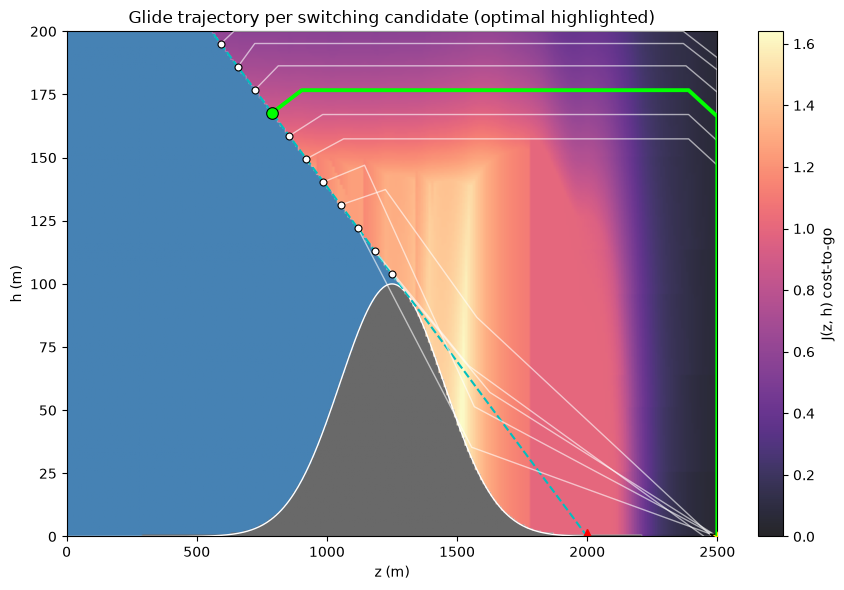

In [14]:
# STEP 6-2 PLOT 1 — Switching-Candidate Glide Trajectory Comparison (load step6_2.json, no recompute)
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

costmap_path = os.path.join(DATA_DIR, 'costmap_2d.json')
with open(costmap_path, 'r') as f:
    cm = json.load(f)
step6_2_path = os.path.join(DATA_DIR, 'step6_2.json')
with open(step6_2_path, 'r') as f:
    s62 = json.load(f)
terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)

z_grid = np.array(cm['z_grid'])
h_grid = np.array(cm['h_grid'])
J_2D = np.array(cm['J_2D'])
terrain_mask_2d = np.array(cm['terrain_mask_2d'], dtype=bool)
occlusion_mask_2d = np.array(cm['occlusion_mask_2d'], dtype=bool)
exclude_mask = np.array(cm['exclude_mask_2d'], dtype=bool)
z_terrain = np.array(terrain_data['z_grid'])
h_terrain_vals = np.array(terrain_data['h_terrain'])
LOS = terrain_data['LOS']

candidates = s62['candidates']
best_idx = s62['best_idx']

TERRAIN_COLOR = 'dimgray'
OCCLUSION_COLOR = 'steelblue'
background = np.zeros((len(z_grid), len(h_grid), 4))
background[occlusion_mask_2d] = mcolors.to_rgba(OCCLUSION_COLOR)
background[terrain_mask_2d] = mcolors.to_rgba(TERRAIN_COLOR)

J_plot = np.where(np.isfinite(J_2D) & ~exclude_mask, J_2D, np.nan)
cmap = plt.get_cmap('magma').copy()
cmap.set_bad(color=(1, 1, 1, 0))
extent = (z_grid[0], z_grid[-1], h_grid[0], h_grid[-1])

plt.figure(figsize=(9, 6))
plt.imshow(np.transpose(background, (1, 0, 2)), origin='lower', extent=extent, aspect='auto')
im = plt.imshow(J_plot.T, origin='lower', extent=extent, aspect='auto', cmap=cmap, alpha=0.85)
plt.colorbar(im, label='J(z, h) cost-to-go')

plt.plot(z_terrain, h_terrain_vals, 'w-', lw=1.0)
los_line = LOS['slope'] * z_grid + LOS['intercept']
plt.plot(z_grid, los_line, 'c--', lw=1.5, label='LOS line')
plt.plot(params['Z_SENSOR'], params['H_SENSOR'], 'r^', markersize=10, label='sensor')
plt.scatter([params['Z_GOAL']], [params['H_GOAL']], c='gold', s=120, marker='*', edgecolors='k', zorder=5, label='goal (J=0)')

for idx, c in enumerate(candidates):
    if not c['reachable']:
        plt.scatter([c['z_sw']], [c['h_sw']], c='gray', marker='x', s=40, zorder=4,
                    label='unreachable candidate (h_sw > H_MAX_GRID)' if idx == 0 else None)
        continue
    is_best = (idx == best_idx)
    plt.plot(c['path_z'], c['path_h'],
              color='lime' if is_best else 'white',
              lw=2.8 if is_best else 1.0,
              alpha=1.0 if is_best else 0.6,
              zorder=6 if is_best else 3,
              label=f'optimal glide (J={c["J"]:.3f})' if is_best else None)
    plt.scatter([c['z_sw']], [c['h_sw']],
                c='lime' if is_best else 'white',
                s=70 if is_best else 25,
                edgecolors='k', linewidths=0.8, zorder=7 if is_best else 4,
                label='optimal switching point' if is_best else None)

plt.xlabel('z (m)')
plt.ylabel('h (m)')
plt.xlim(z_grid[0], z_grid[-1])
plt.ylim(h_grid[0], h_grid[-1])
plt.title('Glide trajectory per switching candidate (optimal highlighted)')
legend_handles, legend_labels = plt.gca().get_legend_handles_labels()
legend_handles += [mpatches.Patch(color=TERRAIN_COLOR, label='terrain'),
                    mpatches.Patch(color=OCCLUSION_COLOR, label='occlusion zone')]
# plt.legend(handles=legend_handles, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

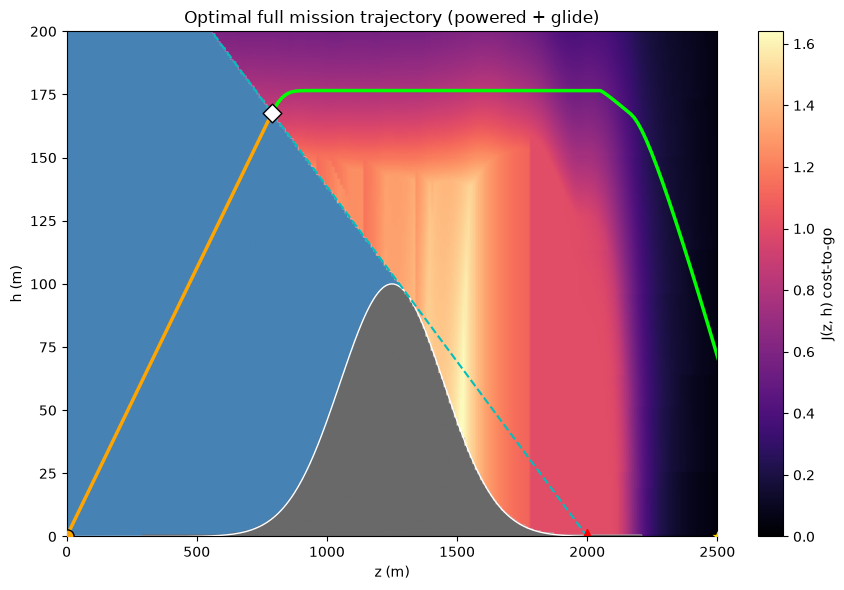

In [15]:
# STEP 6-2 PLOT 2 — Optimal Full Mission Trajectory (load step6_2.json, no recompute)
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

costmap_path = os.path.join(DATA_DIR, 'costmap_2d.json')
with open(costmap_path, 'r') as f:
    cm = json.load(f)
step6_2_path = os.path.join(DATA_DIR, 'step6_2.json')
with open(step6_2_path, 'r') as f:
    s62 = json.load(f)
terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)

z_grid = np.array(cm['z_grid'])
h_grid = np.array(cm['h_grid'])
J_2D = np.array(cm['J_2D'])
terrain_mask_2d = np.array(cm['terrain_mask_2d'], dtype=bool)
occlusion_mask_2d = np.array(cm['occlusion_mask_2d'], dtype=bool)
exclude_mask = np.array(cm['exclude_mask_2d'], dtype=bool)
z_terrain = np.array(terrain_data['z_grid'])
h_terrain_vals = np.array(terrain_data['h_terrain'])
LOS = terrain_data['LOS']

z_traj = np.array(s62['z_traj'])
h_traj = np.array(s62['h_traj'])
powered_end = s62['powered_end_index']
z_sw, h_sw = s62['switching_point']

TERRAIN_COLOR = 'dimgray'
OCCLUSION_COLOR = 'steelblue'
background = np.zeros((len(z_grid), len(h_grid), 4))
background[occlusion_mask_2d] = mcolors.to_rgba(OCCLUSION_COLOR)
background[terrain_mask_2d] = mcolors.to_rgba(TERRAIN_COLOR)

J_plot = np.where(np.isfinite(J_2D) & ~exclude_mask, J_2D, np.nan)
cmap = plt.get_cmap('magma').copy()
cmap.set_bad(color=(1, 1, 1, 0))
extent = (z_grid[0], z_grid[-1], h_grid[0], h_grid[-1])

plt.figure(figsize=(9, 6))
plt.imshow(np.transpose(background, (1, 0, 2)), origin='lower', extent=extent, aspect='auto')
im = plt.imshow(J_plot.T, origin='lower', extent=extent, aspect='auto', cmap=cmap)
plt.colorbar(im, label='J(z, h) cost-to-go')

plt.plot(z_terrain, h_terrain_vals, 'w-', lw=1.0)
los_line = LOS['slope'] * z_grid + LOS['intercept']
plt.plot(z_grid, los_line, 'c--', lw=1.5, label='LOS line')
plt.plot(params['Z_SENSOR'], params['H_SENSOR'], 'r^', markersize=10, label='sensor')

plt.plot(z_traj[:powered_end + 1], h_traj[:powered_end + 1], color='orange', lw=2.5, label='powered phase')
plt.plot(z_traj[powered_end:], h_traj[powered_end:], color='lime', lw=2.5, label='glide phase')

plt.scatter([params['Z_LAUNCH']], [params['H_LAUNCH']], c='orange', s=90, marker='o', edgecolors='k', zorder=6, label='launch')
plt.scatter([z_sw], [h_sw], c='white', s=90, marker='D', edgecolors='k', zorder=6, label='switching point')
plt.scatter([params['Z_GOAL']], [params['H_GOAL']], c='gold', s=120, marker='*', edgecolors='k', zorder=6, label='goal (J=0)')

legend_handles, legend_labels = plt.gca().get_legend_handles_labels()
legend_handles += [mpatches.Patch(color=TERRAIN_COLOR, label='terrain'),
                    mpatches.Patch(color=OCCLUSION_COLOR, label='occlusion zone')]
# plt.legend(handles=legend_handles, loc='upper right', fontsize=8)

plt.xlabel('z (m)')
plt.ylabel('h (m)')
plt.xlim(z_grid[0], z_grid[-1])
plt.ylim(h_grid[0], h_grid[-1])
plt.title('Optimal full mission trajectory (powered + glide)')
plt.tight_layout()
plt.show()

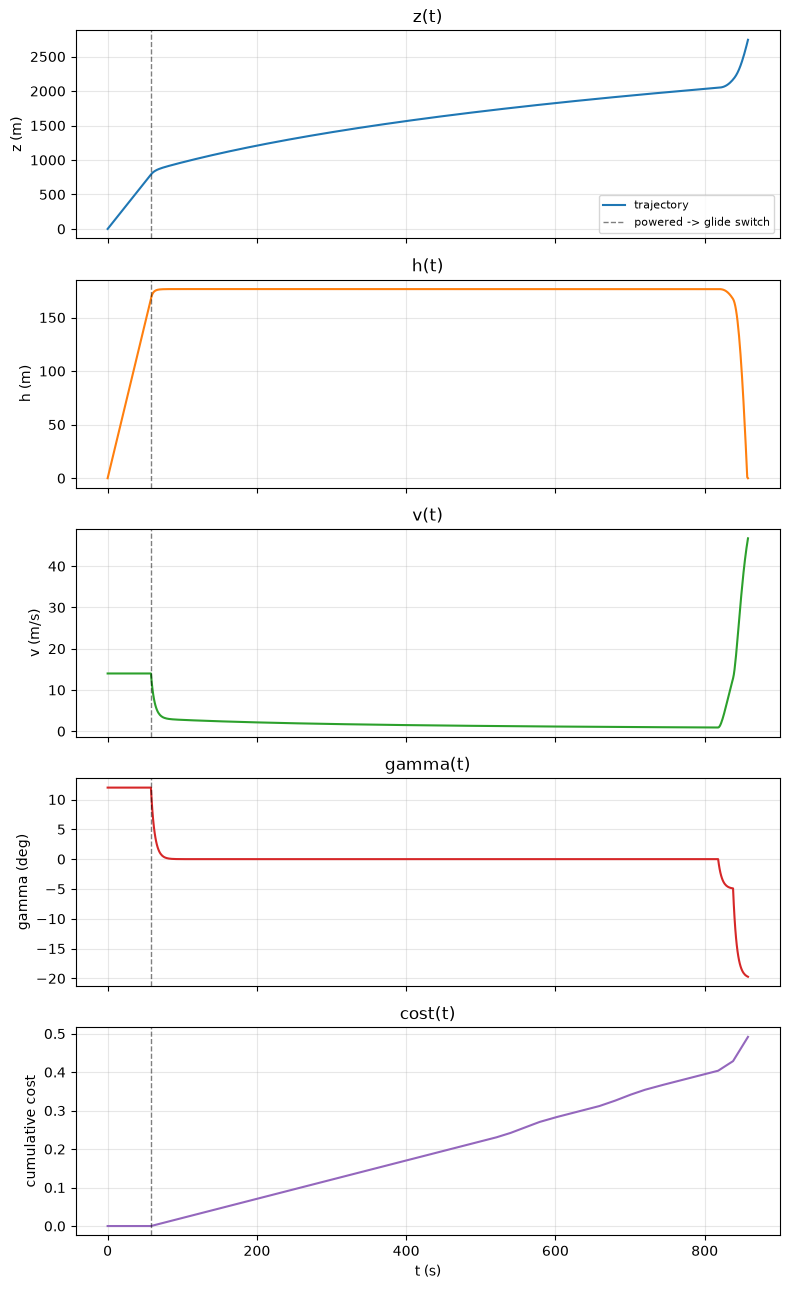

In [16]:
# STEP 6-2 PLOT 3 — Optimal Trajectory State Histories (load step6_2.json, no recompute)
import matplotlib.pyplot as plt
import numpy as np

step6_2_path = os.path.join(DATA_DIR, 'step6_2.json')
with open(step6_2_path, 'r') as f:
    s62 = json.load(f)

t_traj = np.array(s62['t_traj'])
z_traj = np.array(s62['z_traj'])
h_traj = np.array(s62['h_traj'])
v_traj = np.array(s62['v_traj'])
gamma_traj = np.array(s62['gamma_traj'])
cost_traj = np.array(s62['cost_traj'])
t_switch = t_traj[s62['powered_end_index']]

fig, axes = plt.subplots(5, 1, figsize=(8, 13), sharex=True)

series = [
    (z_traj, 'z (m)', 'z(t)', 'tab:blue'),
    (h_traj, 'h (m)', 'h(t)', 'tab:orange'),
    (v_traj, 'v (m/s)', 'v(t)', 'tab:green'),
    (gamma_traj, 'gamma (deg)', 'gamma(t)', 'tab:red'),
    (cost_traj, 'cumulative cost', 'cost(t)', 'tab:purple'),
]

for ax, (y, ylabel, title, color) in zip(axes, series):
    ax.plot(t_traj, y, color=color, label='trajectory')
    ax.axvline(t_switch, color='k', ls='--', lw=1, alpha=0.5, label='powered -> glide switch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=8, loc='best')
axes[-1].set_xlabel('t (s)')
plt.tight_layout()
plt.show()

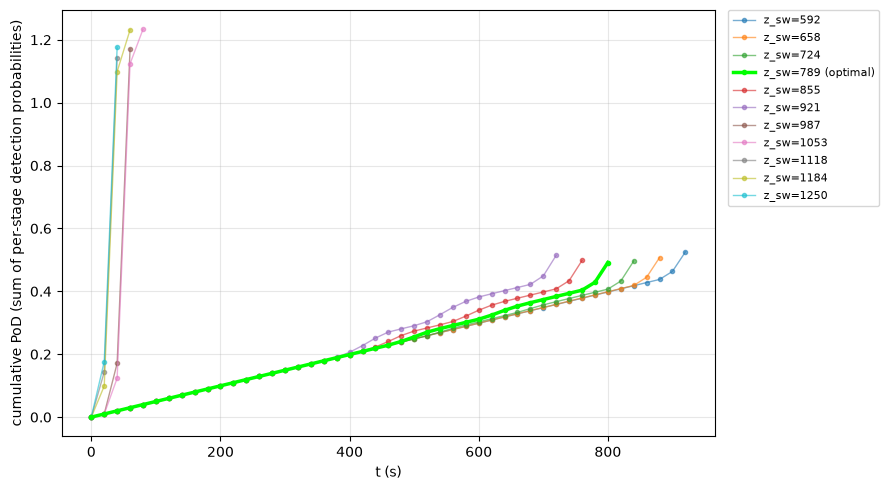

In [17]:
# STEP 6-2 PLOT 4 — Switching-Candidate t vs PoD Comparison (load step6_2.json, no recompute)
import matplotlib.pyplot as plt
import numpy as np

step6_2_path = os.path.join(DATA_DIR, 'step6_2.json')
with open(step6_2_path, 'r') as f:
    s62 = json.load(f)

candidates = s62['candidates']
best_idx = s62['best_idx']

plt.figure(figsize=(9, 5))
for idx, cand in enumerate(candidates):
    if not cand['reachable']:
        continue
    is_best = (idx == best_idx)
    plt.plot(cand['path_t'], cand['path_pod'],
              marker='o', markersize=3,
              color='lime' if is_best else None,
              lw=2.5 if is_best else 1.0,
              alpha=1.0 if is_best else 0.6,
              zorder=5 if is_best else 2,
              label=f'z_sw={cand["z_sw"]:.0f} (optimal)' if is_best else f'z_sw={cand["z_sw"]:.0f}')

plt.xlabel('t (s)')
plt.ylabel('cumulative PoD (sum of per-stage detection probabilities)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()